# [**GABA Neurons in the Amygdala play a central Role in Urocortin-3–Mediated Stress Suppression of Reproduction**](https://www.biorxiv.org/content/10.1101/2025.01.06.631361v1.full). Analysis pipeline + Figures

# 🧰 Preparation Block for Analysis

In [1]:
# Check the current Python version for a stable connection
!python --version

Python 3.10.16


### 📦 Install Required Packages

In [2]:
# Install the Shapely library for geometric operations
!pip install shapely
!pip install colabcode
!pip install colorcet

# Install scikit-posthocs for performing statistical post-hoc tests
!pip install scikit_posthocs
# Install statsmodels module for statistical modeling and hypothesis testing
!python -m pip install statsmodels

### 📥 Importing Required Packages

In [3]:
# OS interface for interacting with the file system
import os

# Core data manipulation and visualisation libraries
import numpy as np                  # Numerical computing (arrays, math functions)
import pandas as pd                 # Data structures & analysis (DataFrame, CSV I/O)
import matplotlib.pyplot as plt     # Plotting library for basic graphs
import colorcet as cc               # Colour maps for visualisation
import seaborn as sns               # Statistical data visualisation, builds on Matplotlib
from pathlib import Path  # Object-oriented filesystem paths

# Advanced plotting tools from Matplotlib
from matplotlib import gridspec           # For custom subplot layouts
from matplotlib.cm import ScalarMappable  # For colour mapping in plots

# Signal processing & statistical functions from SciPy
from scipy.signal import correlate, periodogram          # Signal similarity & frequency analysis
from scipy.cluster.hierarchy import linkage, dendrogram  # Hierarchical clustering & visual trees
from scipy.spatial.distance import pdist, squareform     # Pairwise distance computations
from scipy.stats import mannwhitneyu, kstest, kruskal    # Non-parametric tests
from scipy.linalg import logm, sqrtm                     # Matrix operations for Riemannian geometry
from scipy.stats import t

# Machine learning tools from Scikit-learn
from sklearn.preprocessing import scale, minmax_scale          # Feature scaling methods
from sklearn.cluster import KMeans, AgglomerativeClustering    # Clustering algorithms
from sklearn.metrics import silhouette_score                   # Clustering quality metric

import statsmodels.formula.api as smf  # Statistical modeling using formulas

# Utilities
from itertools import product              # Cartesian product generator (combinatorics)

# Shapes for visualisation
from matplotlib.patches import Ellipse, Polygon                # Custom shapes for plots
from shapely.geometry import Polygon as ShapelyPolygon         # Geometric operations

# Post-hoc statistical tests
from scikit_posthocs import posthoc_dunn    # Dunn’s test for multiple comparisons after Kruskal-Wallis

# Riemannian distance function
from pyriemann.utils.distance import distance_riemann

# ✅ Confirmation
print("Imports done ✅!")

Imports done ✅!


These two sections below are optional. They are only required for consistency of the style of the figures.

In [4]:
# Set the default appearance for Seaborn plots to enhance readability and aesthetics
sns.set_theme(
    context='notebook',       # Context presets size and scaling for notebook display
    style='whitegrid',        # Background grid style for better visual separation
    palette='deep',           # colour palette for plots (rich, vivid colours)
    font='DejaVu Sans',       # Font for labels and titles
    font_scale=1.5,           # Increase font size for better legibility
    rc={                      # Override specific matplotlib parameters
        'lines.linewidth': 2,     # Thicker lines for better visibility
        'lines.markersize': 8,    # Larger markers for clarity
        'xtick.labelsize': 15,    # Font size for x-axis tick labels
        'ytick.labelsize': 15     # Font size for y-axis tick labels
    }
)

In [5]:
# Customise Matplotlib settings for consistent plot styling
rc_params = {
    'axes.grid': False,             # Turn off background gridlines
    'font.family': 'DejaVu Sans',   # Set global font for plot text
    'font.size': 15,                # Base font size for all elements
    'lines.linewidth': 2,           # Make plot lines thicker and easier to read
    'lines.markersize': 8,          # Larger markers for better visibility
    'xtick.major.size': 3,          # Length of major ticks on x-axis
    'ytick.major.size': 3,          # Length of major ticks on y-axis
    'xtick.labelsize': 15,          # Font size for x-axis tick labels
    'ytick.labelsize': 15,          # Font size for y-axis tick labels
    'xtick.bottom': True,           # Show ticks on bottom of x-axis
    'xtick.top': False,             # Hide ticks on top of x-axis
    'ytick.left': True,             # Show ticks on left of y-axis
    'ytick.right': False,           # Hide ticks on right of y-axis
    'axes.edgecolor': 'grey'        # Use grey colour for plot borders
}

# Apply each setting to Matplotlib's runtime configuration
for param, value in rc_params.items():
    plt.rcParams[param] = value

### 🛠 Utility Functions for Your Analysis

Several functions have been defined here to avoid repeating the code; however, in parts, I have repeated these steps with appropriate comments for better readability.

In [6]:
def load_data(stim_csv_fname):
    """
    Load stimulation data from a CSV file and extract relevant cell trace information.

    Parameters:
        stim_csv_fname (str): Path to the CSV file containing stimulation data.

    Returns:
        tuple:
            - data_stim (pd.DataFrame): Entire transposed dataset including metadata.
            - cells_traces_tot_old (pd.DataFrame): Data subset excluding metadata (typically fluorescence traces).
    """

    # Load data from CSV and transpose it (rows become columns and vice versa)
    data_stim = pd.read_csv(stim_csv_fname).T

    # Strip leading/trailing whitespace from index labels to standardise them
    data_stim.index = data_stim.index.str.strip()

    # Extract cell trace data by skipping the first row and column (assumed to be metadata)
    cells_traces_tot_old = data_stim.iloc[1:, 1:]

    # Return both the full dataset and the cleaned subset for downstream use
    return data_stim, cells_traces_tot_old

In [7]:
def process_data(original_data, processed_data, stim_onset=1204, stim_offset=2404, stimulus_freq=0.1, kmeans_clusters=2, random_state=11111):
    """
    Process fluorescence stimulation data to identify and remove noisy/resonating cells
    using frequency-based filtering and K-means clustering.

    Parameters:
        original_data (pd.DataFrame): Raw stimulation data including metadata.
        processed_data (pd.DataFrame): Data with metadata removed (fluorescence traces).
        stim_onset (int): Index of stimulation onset.
        stim_offset (int): Index of stimulation offset.
        stimulus_freq (float): Expected stimulation frequency in Hz (default is 0.1 Hz).
        kmeans_clusters (int): Number of clusters used in K-means (default is 2).
        random_state (int): Seed for reproducible clustering (default is 11111).

    Returns:
        tuple:
            - data_stim_tot (np.ndarray): Cleaned fluorescence data with noisy cells removed.
            - n_cells (int): Number of remaining, reliable cells.
    """

    # Get number of cells (rows) from processed data
    total_cells_stim, _ = processed_data.shape

    # Extract time data from original_data and calculate sampling frequency
    ts_stim_tot = np.asarray(original_data.iloc[0, 1:], dtype=float)
    sec_per_frame = ts_stim_tot[1]
    fs = 1 / sec_per_frame  # Sampling frequency in Hz

    # Convert processed data (traces) to NumPy array for efficient computation
    data_stim_artifact = np.asarray(processed_data, dtype=float)

    # Identify resonating cells via frequency analysis (Periodogram)
    labels_removed_PSD = []
    for i in range(total_cells_stim):
        freq, Pxx_den = periodogram(data_stim_artifact[i, stim_onset:stim_offset], fs)
        Pxx_den = Pxx_den / max(Pxx_den)  # Normalise power
        freq_bin = round(stimulus_freq * (stim_offset - stim_onset) / fs)
        if Pxx_den[freq_bin] > 0.37:
            labels_removed_PSD.append(i)  # Mark as resonating

    # Create binary mask of valid vs. resonating cells
    labels_artifact = np.array([0 if i in labels_removed_PSD else 1 for i in range(total_cells_stim)])

    # Apply K-means clustering to activity during stimulus period
    km = KMeans(n_clusters=kmeans_clusters, random_state=random_state, n_init=10, max_iter=100)
    clustered = scale(data_stim_artifact[:, stim_onset:stim_offset], axis=0)
    km.fit(clustered)
    labels_artifact_KM = km.labels_

    # Identify which cluster is smaller (assumed artifact) and remove it
    cluster_removed = 0 if np.sum(labels_artifact_KM == 0) < np.sum(labels_artifact_KM == 1) else 1
    for i in range(len(data_stim_artifact)):
        if labels_artifact[i] == 1 and labels_artifact_KM[i] == cluster_removed:
            labels_artifact[i] = 0  # Remove cell

    # Extract indices of removed cells and drop them
    labels_removed = np.where(labels_artifact == 0)[0]
    removed_row_labels = processed_data.index[labels_removed]
    cells_traces_stim_tot = processed_data.drop(removed_row_labels, axis=0, inplace=False)

    # Convert final cleaned DataFrame to NumPy array
    data_stim_tot = np.asarray(cells_traces_stim_tot, dtype=float)

    # Return cleaned data and count of remaining cells
    n_cells = len(cells_traces_stim_tot)
    return data_stim_tot, n_cells

In [8]:
def min_max_norm(data):
    """
    Min-Max normalise each trace (row) independently to [0, 1].
    """
    data = np.asarray(data)
    min_vals = np.min(data, axis=1, keepdims=True)
    max_vals = np.max(data, axis=1, keepdims=True)

    return (data - min_vals) / (max_vals - min_vals)

In [9]:
# Convert p-value to custom significance symbols for visualisation
def pval_to_star(pvalue):
    """
    Converts a p-value into a string representing significance levels using hash marks and daggers.

    Parameters:
        pvalue (float): The p-value to evaluate.

    Returns:
        str: A string indicating statistical significance:
            '##'   → Highly significant (p ≤ 0.001)
            '#'    → Significant (p ≤ 0.01)
            '†'    → Marginally significant (p ≤ 0.05)
            'ns'   → Not significant
    """
    if pvalue <= 0.0001:
        return '##'  # Extremely significant
    elif pvalue <= 0.001:
        return '##'  # Highly significant
    elif pvalue <= 0.01:
        return '#'   # Significant
    elif pvalue <= 0.05:
        return '†'   # Marginally significant
    else:
        return 'ns'  # Not significant

In [10]:
# Compute a metric based on signed lagged cross-correlation (SLxCorr)
def signed_lagged_corr(x, y, demean=True):
    """
    Computes the signed lagged cross-correlation between two signals and returns the
    correlation value at the lag with the maximum absolute correlation, along with that lag.

    Parameters:
        x (numpy.ndarray): First input signal (1D).
        y (numpy.ndarray): Second input signal (1D).
        demean (bool): If True, subtract the mean from each signal before correlation.

    Returns:
        tuple:
            - float: Signed, normalised cross-correlation at the peak absolute correlation.
            - int: Lag (in samples) corresponding to that peak. Positive lag means y lags x.
    """
    # Ensure 1D arrays
    x = np.asarray(x).ravel()
    y = np.asarray(y).ravel()

    # Optionally remove DC offset so correlation focuses on shape, not level
    if demean:
        x = x - x.mean()
        y = y - y.mean()

    # Guard against zero-variance inputs
    norm = np.linalg.norm(x) * np.linalg.norm(y)
    if norm == 0:
        raise ValueError("Normalisation factor is zero. Ensure signals have non-zero variance.")

    # Full cross-correlation; zero lag is at index len(y) - 1 for correlate(x, y)
    cross_corr = correlate(x, y, mode='full')
    scc = cross_corr / norm                   # Normalised cross-correlation
    abs_scc = np.abs(scc)

    # Peak absolute correlation and its lag
    max_idx = int(np.argmax(abs_scc))
    lag = max_idx - (len(y) - 1)              # Convert index to lag (centered at zero lag)
    signed_correlation = float(scc[max_idx])  # Keep the sign at the peak

    return signed_correlation, lag

In [11]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
# run the risky operations here

# Generate mean and standard deviation of Riemannian distances for SPD (correlation) matrices of sizes p=5–80
def metropolis_hastings(p, component_index, num_samples=2000, burn_in=200, proposal_std=0.01):
    """
    Generate random correlation matrix components using Metropolis–Hastings sampling on the unit sphere.

    Parameters:
        p (int): Dimension of the full correlation matrix.
        component_index (int): Index of the component being generated (1-based).
        num_samples (int): Number of samples to retain after burn-in.
        burn_in (int): Number of initial samples to discard to allow convergence.
        proposal_std (float): Standard deviation of the Gaussian proposal noise.

    Returns:
        numpy.ndarray: Array of shape (num_samples, dim) containing generated unit vectors.
    """
    dim = p - component_index + 1  # Effective dimension of the current component
    samples = np.zeros((burn_in + num_samples + 1, dim))

    # Initialise with a random unit vector; ensure first component is non-negative
    current = np.random.randn(1, dim)
    current[0, 0] = np.abs(current[0, 0])
    current = current / np.linalg.norm(current)

    # Run Metropolis–Hastings chain
    for t in range(burn_in + num_samples + 1):
        # Propose a new vector with small Gaussian perturbation
        proposal = current + np.random.normal(scale=proposal_std, size=(1, dim))
        proposal = proposal / np.linalg.norm(proposal)  # Renormalise to unit length

        # Compute acceptance ratio (ensuring positivity of first component)
        delta = np.random.uniform(0, 1)
        acceptance_ratio = (proposal[0, 0] / current[0, 0])**component_index if proposal[0, 0] >= 0 else 0

        # Accept or reject proposal
        if delta < acceptance_ratio:
            current = proposal

        samples[t, :] = current.flatten()

    # Return only the post-burn-in samples
    return samples[burn_in + 1:, :]


def random_correlation_matrix(p):
    """
    Construct a random correlation matrix of size p × p using Metropolis–Hastings sampling.

    Each row of the upper-triangular matrix U is sampled sequentially, and the
    final correlation matrix is obtained as C = U Uᵀ, normalised to have unit diagonal.

    Parameters:
        p (int): Dimension of the correlation matrix.

    Returns:
        numpy.ndarray: Random correlation matrix of size p × p.
    """
    U = np.zeros((p, p))
    for i in range(p):
        # For each row i, sample the corresponding unit vector and use the last draw
        U[i, i:] = metropolis_hastings(p, i + 1)[-1, :]

    # Compute symmetric product and normalise diagonal entries to 1
    C = U @ U.T
    D = np.sqrt(np.diag(C))
    correlation_matrix = C / np.outer(D, D)
    return correlation_matrix


def distance_riemann(A, B):
    """
    Compute the affine-invariant Riemannian distance between two SPD matrices A and B.

    Formula:
        d(A, B) = || log( A^{-1/2} B A^{-1/2} ) ||_F

    Parameters:
        A (numpy.ndarray): First SPD matrix.
        B (numpy.ndarray): Second SPD matrix.

    Returns:
        float: The affine-invariant Riemannian distance between the two matrices.
    """
    sqrt_A = sqrtm(A)
    inv_sqrt_A = np.linalg.inv(sqrt_A)
    C = inv_sqrt_A @ B @ inv_sqrt_A
    log_C = logm(C)
    return np.linalg.norm(log_C, 'fro')


def expected_distance(matrix_size, num_pairs=100):
    """
    Estimate the expected Riemannian distance (mean ± std) between pairs of
    random correlation matrices of a given size.

    Parameters:
        matrix_size (int): Dimension of the correlation matrices.
        num_pairs (int): Number of pairs of matrices to generate.

    Returns:
        tuple:
            - float: Mean of the estimated distances.
            - float: Standard deviation of the estimated distances.
    """
    distances = []
    for _ in range(num_pairs):
        A = random_correlation_matrix(matrix_size)
        B = random_correlation_matrix(matrix_size)
        d = distance_riemann(A, B)
        distances.append(d)

    return np.mean(distances), np.std(distances)



In [12]:
# Main loop: compute and display mean and standard deviation of distances
# for matrix sizes ranging from 5 to 80
# mean_d = {}
# std_d = {}
# for n in range(5, 81):
#     mean_tmp, std_tmp = expected_distance(n, num_pairs=100)
#     print(f"{n}x{n}: Mean: {mean_tmp:.4f}, Standard Deviation: {std_tmp:.4f}")

#     mean_d[n] = mean_tmp
#     std_d[n] = std_tmp
    




In [13]:
def compute_AUC(data_tot, stim_onset, stim_offset):
    """
    Compute the change in area under the curve (AUC) of ΔF/F signals before and during stimulation.

    Parameters:
        data_tot (numpy.ndarray): 2D array of calcium fluorescence signals
                                  (shape: n_cells × n_timepoints).
        stim_onset (int): Frame index marking the start of stimulation.
        stim_offset (int): Frame index marking the end of stimulation.

    Notes:
        - ΔF/F (delta F over F) is computed relative to the mean baseline fluorescence
          during the pre-stimulation period.
        - AUC is computed for several time windows (30, 60, 90, 120 seconds)
          within the stimulation period.
        - Sampling rate is assumed to be 10 Hz (hence `time_point * 10`).
    """

    AUC_time_windows = [30, 60, 90, stim_offset/10]  # time windows (in seconds) for which AUC is computed

    # --- Pre-stimulation ΔF/F computation ---
    # Compute mean baseline for each cell during pre-stimulation period
    baseline_pre = np.mean(data_tot[:, :stim_onset], axis=1)
    # Compute ΔF/F trace for pre-stimulation
    dff_pre = (data_tot[:, :stim_onset] - baseline_pre[:, np.newaxis]) / baseline_pre[:, np.newaxis]

    # --- Stimulation ΔF/F computation ---
    # Compute mean baseline again (same as above, to ensure comparable scaling)
    baseline_stim = np.mean(data_tot[:, :stim_onset], axis=1)
    # Compute ΔF/F trace during stimulation
    dff_stim = (data_tot[:, stim_onset:stim_offset] - baseline_stim[:, np.newaxis]) / baseline_stim[:, np.newaxis]

    # --- Compute AUC differences for each time window ---
    for AUC_window in AUC_time_windows:
        # Compute average AUC for pre-stimulation (normalised by duration)
        area_1 = np.trapezoid(dff_pre) / (stim_onset / 10)

        # Compute average AUC during stimulation (up to specified duration)
        # Sampling rate assumed 10 Hz → convert seconds to frame index.
        area_2 = np.trapezoid(dff_stim[:, :AUC_window * 10]) / AUC_window

        # Output median difference in AUC between stimulation and pre-stimulation
        print(f'AUC for {AUC_window} s is {np.median(area_2) - np.median(area_1)}.')

### 📁 Setting File Paths for Figures and Data

In [14]:
# --- Fig. 1: Stimulation and Stress Data ---
stim_fig1_csv_fname = './data/calcium_imaging/UCN3_stimulation/G7 20240201 10hz 223sti.csv'
stress_fig1_csv_fname = './data/calcium_imaging/restrain_stress/G28 333restraint 20240630.csv'

# --- Fig. 2: Stimulation and Stress Data ---
stim_fig2_csv_fname = './data/calcium_imaging/UCN3_stimulation/G28 20240709 10hz 223sti.csv'
stress_fig2_csv_fname = './data/calcium_imaging/restrain_stress/G9 20231218 334restraint.csv'

# --- Figs. 1 & 2: P-values and Cell Percentages ---
hier_clustering_cell_perc_fname = './data/cell_percentage_hier_corr 10Hz.csv'


if not Path(stim_fig1_csv_fname).is_file():
    print(f"File {stim_fig1_csv_fname} does not exist")
if not Path(stress_fig1_csv_fname).is_file():
    print(f"File {stim_fig1_csv_fname} does not exist")
if not Path(stim_fig2_csv_fname).is_file():
    print(f"File {stim_fig1_csv_fname} does not exist")
if not Path(stress_fig2_csv_fname).is_file():
    print(f"File {stim_fig1_csv_fname} does not exist")
if not Path(hier_clustering_cell_perc_fname).is_file():
    print(f"File {hier_clustering_cell_perc_fname} does not exist")             


In [15]:
# --- Time Windows (in index units) ---
stim_onset = 1204
stim_offset = 2404
stress_onset = 1804
stress_offset = 3604

# --- Signal Analysis ---
PSD_thr = 0.37  # Power Spectral Density threshold

# --- Clustering & Bootstrapping ---
max_no_clusters = 4
n_resampling = 100
Ks_1 = 2  # Pre-stimulation clusters
Ks_2 = 2  # Stimulation clusters

# --- GABA Neuron colours ---
eff_green = (63/255, 128/255, 0)  # GABA efferent
inter_green = (0, 1, 0)           # GABA interneuron
GABA_greens = [eff_green, inter_green]

# 🧪 Full Workflow: G7 Stimulation (Figures 1 & S1)

This is an example stimulation trial for figure 1 from animal G7.

In [16]:
# Load and transpose the data
data_fig1_stim = pd.read_csv(stim_fig1_csv_fname).T

# Clean up row labels
data_fig1_stim.index = data_fig1_stim.index.str.strip()

# Preview the last 5 cells
data_fig1_stim.tail(5)

,0,1,2,3,4,5,6,7,8,9,...,4191,4192,4193,4194,4195,4196,4197,4198,4199,4200
C103,accepted,0,163.1273,204.9808,364.2087,468.3113,567.8976,677.4635,748.3613,796.7478,...,1481.325,1529.364,1579.26,1507.688,1439.359,1374.127,1311.851,1252.398,1195.639,1141.452
C123,accepted,0,99.10083,105.4489,161.1735,306.0283,388.1881,453.6874,650.0859,659.4799,...,881.6087,958.0846,917.092,877.8534,840.2936,804.3409,769.9264,736.9843,705.4518,675.2684
C132,accepted,0,10.57336,120.8523,114.5652,108.6052,102.9553,185.2916,196.7083,186.4749,...,855.0981,810.6134,768.4429,784.4611,824.1917,814.8,925.5956,877.4434,831.7961,788.5236
C133,accepted,0,0,65.93188,62.74615,59.71429,229.1379,218.0662,283.8481,270.1328,...,1234.254,1174.616,1188.296,1350.335,1285.088,1222.993,1163.899,1107.66,1054.139,1003.204
C142,accepted,0,0,0,119.6319,113.9691,177.2393,168.8497,160.8573,153.2431,...,1359.469,1295.119,1397.036,1330.908,1267.91,1274.764,1214.424,1485.744,1415.417,1348.419


## ✂️ Data Slicing for G7 Stimulation

In [17]:
# Extract signal data (excluding metadata)
cells_traces_tot_old = data_fig1_stim.iloc[1:, 1:]

# Get shape info
total_cells_fig1_stim, data_fig1_stim_length_tot = cells_traces_tot_old.shape

# Preview bottom rows
cells_traces_tot_old.tail()

,1,2,3,4,5,6,7,8,9,10,...,4191,4192,4193,4194,4195,4196,4197,4198,4199,4200
C103,0,163.1273,204.9808,364.2087,468.3113,567.8976,677.4635,748.3613,796.7478,760.639,...,1481.325,1529.364,1579.26,1507.688,1439.359,1374.127,1311.851,1252.398,1195.639,1141.452
C123,0,99.10083,105.4489,161.1735,306.0283,388.1881,453.6874,650.0859,659.4799,631.2634,...,881.6087,958.0846,917.092,877.8534,840.2936,804.3409,769.9264,736.9843,705.4518,675.2684
C132,0,10.57336,120.8523,114.5652,108.6052,102.9553,185.2916,196.7083,186.4749,176.774,...,855.0981,810.6134,768.4429,784.4611,824.1917,814.8,925.5956,877.4434,831.7961,788.5236
C133,0,0,65.93188,62.74615,59.71429,229.1379,218.0662,283.8481,270.1328,368.981,...,1234.254,1174.616,1188.296,1350.335,1285.088,1222.993,1163.899,1107.66,1054.139,1003.204
C142,0,0,0,119.6319,113.9691,177.2393,168.8497,160.8573,153.2431,262.6978,...,1359.469,1295.119,1397.036,1330.908,1267.91,1274.764,1214.424,1485.744,1415.417,1348.419


In [18]:
# Extract time axis from first row (excluding first column)
ts_fig1_stim_tot = np.asarray(data_fig1_stim.iloc[0, 1:], dtype=float)

# Time between frames (first timestamp is 0)
sec_per_frame = ts_fig1_stim_tot[1]

# Sampling frequency (Hz)
fs = 1 / sec_per_frame

In [19]:
# Convert fluorescence traces to NumPy array
data_fig1_stim_artifact = np.asarray(cells_traces_tot_old, dtype=float)

## 🔍 Finding UCN3 Cells

### 🌀 1. Power Spectral Density (PSD) Filtering

In [20]:
# Define the stimulus frequency and initialise a list to store labels of removed cells based on PSD threshold
stimulus_freq = 0.1  # Stimulus frequency in Hz
labels_removed_PSD = []  # List to store indices of cells flagged as responsive

# Loop through each cell to calculate the power spectral density (PSD)
for i in range(total_cells_fig1_stim):
    # Compute the periodogram (PSD) for the cell's signal during the stimulation period
    freq, Pxx_den = periodogram(
        data_fig1_stim_artifact[i, stim_onset:stim_offset], fs)

    # Normalise the PSD by its maximum value to scale between 0 and 1
    Pxx_den = Pxx_den / max(Pxx_den)

    # Calculate the index corresponding to the stimulus frequency
    # This assumes uniform frequency spacing in the PSD output
    stimulus_freq_idx = round(stimulus_freq * (stim_offset - stim_onset) / fs)

    # Check if the normalised PSD at the stimulus frequency exceeds the threshold
    if Pxx_den[stimulus_freq_idx] > PSD_thr:
        # If so, mark the cell as responsive by adding its index to the list
        labels_removed_PSD.append(i)

# Print the indices of cells identified as responsive based on PSD threshold
print("Indices of cells removed based on PSD threshold:", labels_removed_PSD)

Indices of cells removed based on PSD threshold: [22, 25, 26]


In [21]:
#   Create binary mask to flag artifact-affected cells
# - 0: cell identified as artifact (high PSD at stimulus frequency)
# - 1: cell retained for further analysis
labels_artifact = np.asarray(
    [0 if _ in labels_removed_PSD else 1 for _ in range(total_cells_fig1_stim)]
)

# Optional: Print the binary mask to verify which cells were flagged
# 0 = artifact (failed PSD threshold), 1 = valid (passed PSD threshold)
print(labels_artifact)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1]


### 🔢 2. K-Means Clustering

In [22]:
# Apply scikit-learn K-means clustering to sort activity traces

# Step 1: Normalise the activity data across time (columns) to ensure fair clustering
scaled_data = scale(data_fig1_stim_artifact[:, stim_onset:stim_offset], axis=0)

# Step 2: Set the number of clusters (2 groups: responsive vs non-responsive)
Ks = 2

# Step 3: Initialise and run K-means clustering
# - random_state ensures reproducibility
# - n_init = 10 means the algorithm runs 10 times with different centroid seeds
# - max_iter = 100 limits the number of iterations per run
kmeans = KMeans(n_clusters=Ks, random_state=11111, n_init=10, max_iter=100)

# Step 4: Fit the model to the scaled data and assign cluster labels to each cell
labels_artifact_KM = kmeans.fit_predict(scaled_data)

# Step 5: Sort cell indices based on their assigned cluster labels
# This helps organise or visualise cells by their activity patterns
i_labels_artifact = np.argsort(labels_artifact_KM)

# Step 6: Display the sorted indices for inspection or downstream analysis
print(f"Sorted indices of cells by cluster ID:\n{i_labels_artifact}")

Sorted indices of cells by cluster ID:
[ 0  1  2  3  4  5  6  7  8  9 10 11 13 14 15 16 29 17 21 20 27 31 45 44
 40 41 42 38 36 35 34 33 46 43 30 28 24 18 22 23 19 12 25 26 39 37 32]


In [23]:
# Determine which cluster to remove based on relative size

# Step 1: Count the number of cells in each cluster
size_cluster_0 = len(data_fig1_stim_artifact[labels_artifact_KM == 0])
size_cluster_1 = len(data_fig1_stim_artifact[labels_artifact_KM == 1])

# Step 2: Compare cluster sizes to identify the smaller one
# The assumption here is that the smaller cluster likely represents artifacts or noise
if size_cluster_0 < size_cluster_1:
    cluster_removed = 0  # Smaller cluster is flagged for removal
    cluster_kept = 1     # Larger cluster is retained
    print('Cluster #0 (smaller) is removed.')
elif size_cluster_1 != 0:
    cluster_removed = 1
    cluster_kept = 0
    print('Cluster #1 (smaller) is removed.')
else:
    # Edge case: one cluster has zero members, so no valid removal decision
    print("No valid cluster for removal.")

Cluster #1 (smaller) is removed.


In [24]:
# Update artifact labels based on K-means clustering results

# Step 1: Check if the cluster marked for removal contains any cells
if len(data_fig1_stim_artifact[labels_artifact_KM == cluster_removed]) != 0:
    # Step 2: Iterate through all cells
    for i in range(len(data_fig1_stim_artifact)):
        # Only update cells that were previously marked as valid (1)
        # and now belong to the cluster flagged for removal
        if labels_artifact[i] == 1 and labels_artifact_KM[i] == cluster_removed:
            labels_artifact[i] = 0  # Mark as artifact

# Step 3: Explicitly define which cluster was removed and which was kept
cluster_removed = 0
cluster_kept = 1

# Step 4: Extract indices of cells now marked as artifacts
labels_removed = np.where(labels_artifact == cluster_removed)[0]

# Optional: print summary for verification
print(f"Number of (UCN) cells removed: {len(labels_removed)}")
print(f"Indices of removed cells: {labels_removed}")

Number of (UCN) cells removed: 13
Indices of removed cells: [12 18 19 22 23 24 25 26 28 30 32 37 39]


In [25]:
# Remove resonated (artifact) cells from fluorescence intensity traces

# Step 1: Get the row labels (e.g., cell IDs) corresponding to removed indices
removed_row_labels = cells_traces_tot_old.index[labels_removed]

# Step 2: Drop the identified artifact cells from the original DataFrame
# - axis=0 means rows are being removed
# - inplace=False ensures the original DataFrame remains unchanged
cells_traces_fig1_stim_tot = cells_traces_tot_old.drop(
    removed_row_labels, axis=0, inplace=False)

# Step 3: Count the number of remaining (valid) cells after removal
n_cells_fig1_stim = len(cells_traces_fig1_stim_tot)

# Optional: print summary
print(f"Number of GABA cells: {n_cells_fig1_stim}")

Number of GABA cells: 34


### ✂️ Data Slicing

In [26]:
# Convert filtered fluorescence traces from DataFrame to NumPy array
data_fig1_stim_tot = cells_traces_fig1_stim_tot.to_numpy(dtype=float)

# Slice the data into temporal segments for analysis
# Pre-stimulation period: from start up to stimulus onset
data_fig1_stim_1 = data_fig1_stim_tot[:, :stim_onset]

# Stimulation period: from stimulus onset to stimulus offset
data_fig1_stim_2 = data_fig1_stim_tot[:, stim_onset:stim_offset]

# Optional: Print shapes to verify correct slicing
print(f"Total data shape: {data_fig1_stim_tot.shape}")
print(f"Pre-stimulation data shape: {data_fig1_stim_1.shape}")
print(f"Stimulation data shape: {data_fig1_stim_2.shape}")

Total data shape: (34, 4200)
Pre-stimulation data shape: (34, 1204)
Stimulation data shape: (34, 1200)


In [27]:
# Rescale pre-stimulation traces using min-max normalisation (row-wise)
normalised_data_fig1_stim_1 = minmax_scale(data_fig1_stim_1, axis=1)

# Optional: Inspect the first few normalised traces to verify the transformation
print("Normalised Pre-stimulation Data (first few rows):")
print(normalised_data_fig1_stim_1[:5])

Normalised Pre-stimulation Data (first few rows):
[[0.00000000e+00 5.97838127e-02 5.69899301e-02 ... 2.00328406e-01
  1.90966469e-01 1.82041998e-01]
 [9.51529751e-10 9.51529751e-10 9.51529751e-10 ... 1.45800425e-02
  5.36232341e-02 7.53780488e-02]
 [0.00000000e+00 1.17174412e-01 1.12128684e-01 ... 2.37355708e-01
  2.27134832e-01 2.17354135e-01]
 [0.00000000e+00 8.24870575e-03 6.03542529e-02 ... 6.25703007e-01
  5.99132250e-01 5.83043338e-01]
 [0.00000000e+00 7.17982972e-02 2.39288441e-01 ... 8.49505749e-01
  8.60574750e-01 8.32647040e-01]]


In [28]:
# Rescale stimulation-period traces using min-max normalisation (row-wise)
normalised_data_fig1_stim_2 = minmax_scale(data_fig1_stim_2, axis=1)

# Optional: Inspect the first few normalised stimulation traces
print("Normalised Stimulation Data (first few rows):")
print(normalised_data_fig1_stim_2[:5])

Normalised Stimulation Data (first few rows):
[[0.06445198 0.06138917 0.05846949 ... 0.09354629 0.08912381 0.08490801]
 [0.0329     0.03139735 0.02995959 ... 0.13025095 0.12454536 0.11908607]
 [0.43510967 0.41624471 0.50271502 ... 0.38905291 0.37217111 0.42760958]
 [0.80625883 0.82709348 0.89880095 ... 0.11961902 0.11375671 0.10814338]
 [0.77175663 0.73518196 0.73477366 ... 0.00243167 0.00231622 0.00220625]]


### 📈 corrcoef: Standard Pearson Correlation Coefficient

In [29]:
# Compute the correlation matrix for pre-stimulation traces
max_corr_fig1_stim_1 = np.corrcoef(normalised_data_fig1_stim_1, rowvar=True)

# Compute the correlation matrix for stimulation-period traces
max_corr_fig1_stim_2 = np.corrcoef(normalised_data_fig1_stim_2, rowvar=True)

## 🖼️ Figure S1: Visualisation of Trace Filtering and Clustering

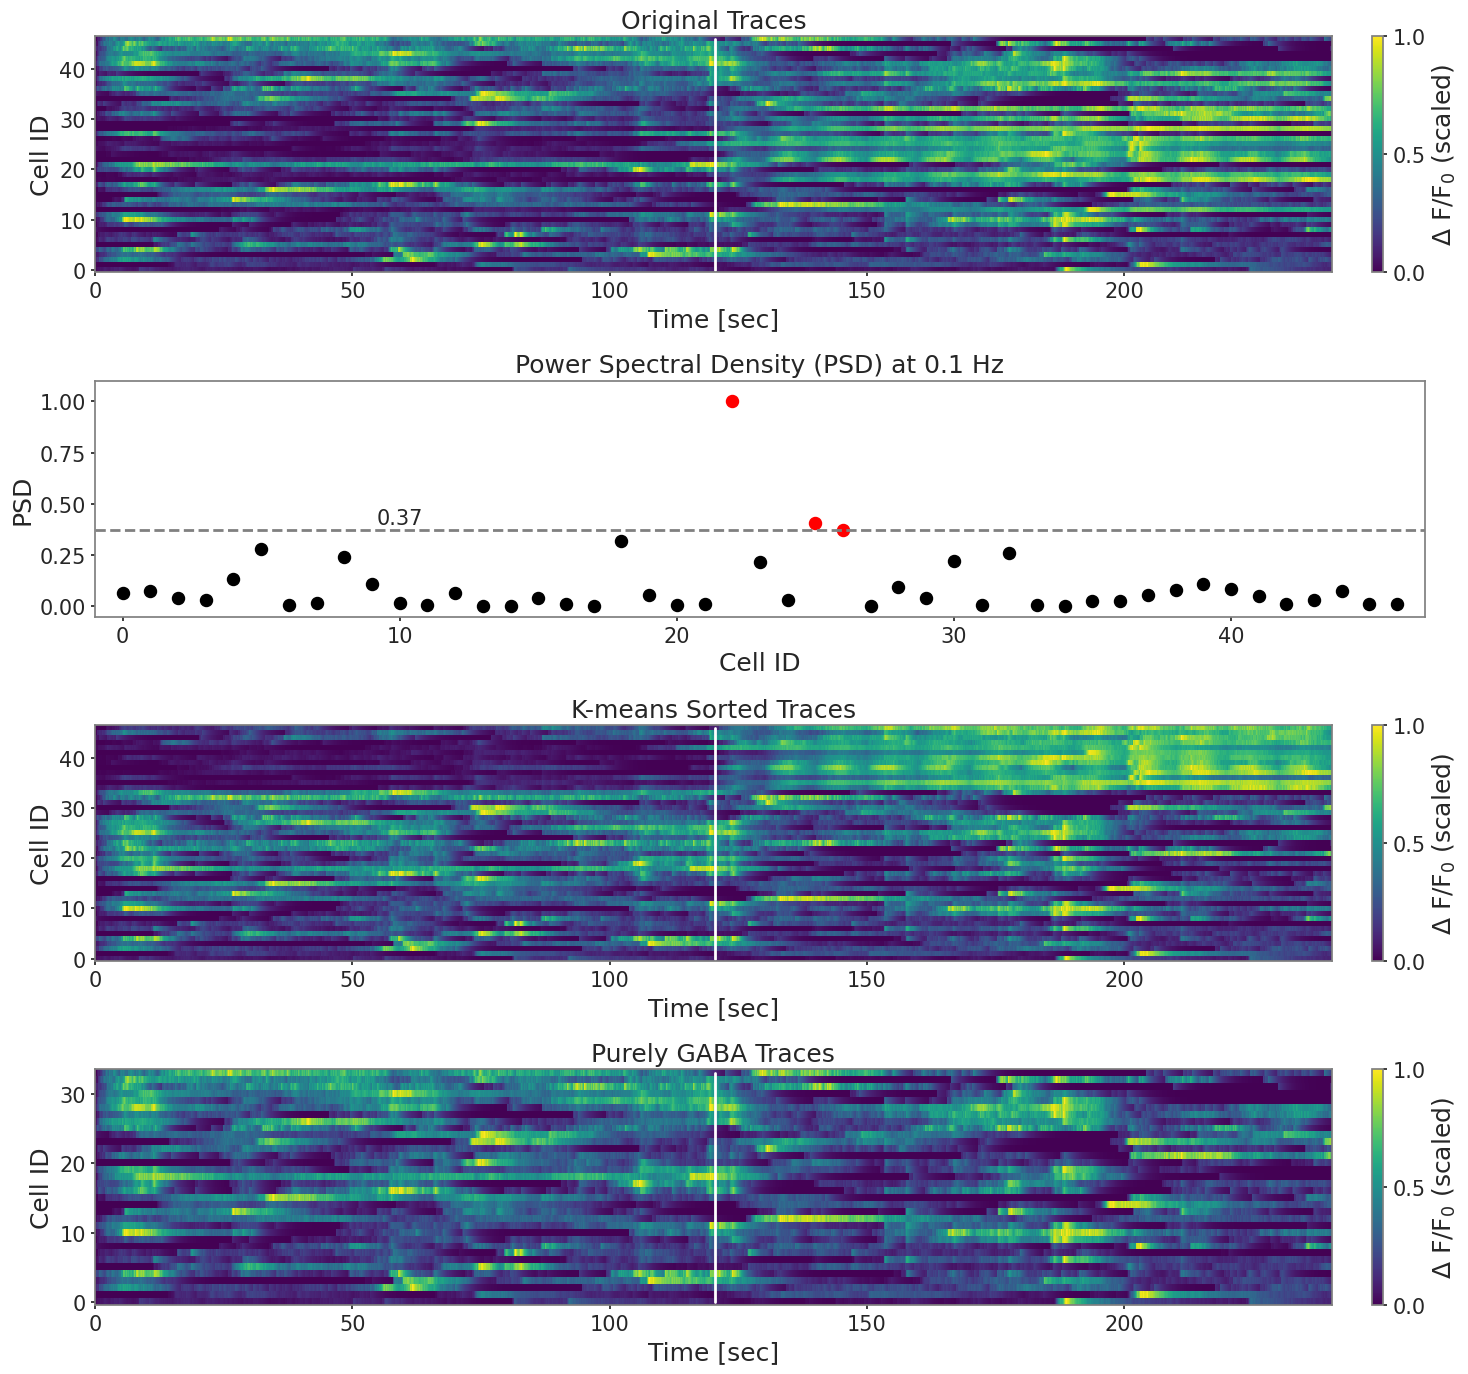

In [30]:
# Set up the figure canvas with 4 vertical subplots
plt.figure(figsize=(15, 14))

# ─────────────────────────────────────────────────────────────
# 🔹 Plot 1: Original Traces (before any filtering)
ax1 = plt.subplot(4, 1, 1)

# Normalise raw traces for visualisation
scaled_data = minmax_scale(data_fig1_stim_artifact[:, :stim_offset], axis=1)

# Display as heatmap
plt.imshow(scaled_data, cmap="viridis", interpolation='none')

# Mark stimulus onset with a vertical white line
ax1.plot([1204, 1204], [0, total_cells_fig1_stim-1], '-w')

# Configure plot aesthetics
ax1.set_aspect('auto')
ax1.set_xlabel('Time [sec]')
ax1.set_ylabel('Cell ID')
ax1.invert_yaxis()
ax1.set_title('Original Traces')
ax1.set_xticks([0, 500, 1000, 1500, 2000])
ax1.set_xticklabels([0, 50, 100, 150, 200])

# Add colourbar for ΔF/F₀ intensity
cmap = plt.get_cmap("viridis")
sm = ScalarMappable(cmap=cmap)
sm.set_clim(vmin=0, vmax=1)
cb = plt.colorbar(cmap=cmap, fraction=0.04, pad=0.03)
cb.set_label('$\Delta$ F$/$F$_0$ (scaled)')
cb.set_ticks([0, 0.5, 1])

# ─────────────────────────────────────────────────────────────
# 🔹 Plot 2: Power Spectral Density (PSD) at 0.1 Hz
ax2 = plt.subplot(4, 1, 2)

# Loop through each cell to compute and plot PSD
for i in range(total_cells_fig1_stim):
    freq, Pxx_den = periodogram(data_fig1_stim_artifact[i, stim_onset:stim_offset], fs)
    Pxx_den = Pxx_den / max(Pxx_den)  # Normalise PSD
    stimulus_freq_PSD = Pxx_den[round(stimulus_freq * (stim_offset - stim_onset) / fs)]

    # Mark cells based on PSD threshold
    if stimulus_freq_PSD < PSD_thr:
        labels_removed_PSD.append(i)
        ax2.scatter(i, stimulus_freq_PSD, marker='.', s=300, c='black')  # Below threshold
    else:
        ax2.scatter(i, stimulus_freq_PSD, marker='.', s=300, c='red')    # Above threshold

# Add horizontal threshold line
ax2.plot([-1, total_cells_fig1_stim], [0.37, 0.37], '--', c='gray')
ax2.set_xlim([-1, total_cells_fig1_stim])
ax2.set_ylim([-0.05, 1.1])
ax2.set_xlabel('Cell ID')
ax2.set_ylabel('PSD')
ax2.set_title('Power Spectral Density (PSD) at 0.1 Hz')
ax2.annotate(0.37, (10, 0.4), ha='center')

# ─────────────────────────────────────────────────────────────
# 🔹 Plot 3: Traces Sorted by K-means Clustering
ax3 = plt.subplot(4, 1, 3)

# Display sorted traces based on clustering labels
plt.imshow(minmax_scale(data_fig1_stim_artifact[i_labels_artifact, :stim_offset], axis=1), cmap="viridis", interpolation='none')

# Mark stimulus onset
ax3.plot([1204, 1204], [0, total_cells_fig1_stim-1], '-w')

# Configure plot aesthetics
ax3.set_aspect('auto')
ax3.set_xlabel('Time [sec]')
ax3.set_ylabel('Cell ID')
ax3.invert_yaxis()
ax3.set_title('K-means Sorted Traces')
ax3.set_xticks([0, 500, 1000, 1500, 2000])
ax3.set_xticklabels([0, 50, 100, 150, 200])

# Add colourbar
cmap = plt.get_cmap("viridis")
sm = ScalarMappable(cmap=cmap)
sm.set_clim(vmin=0, vmax=1)
cb = plt.colorbar(cmap=cmap, fraction=0.04, pad=0.03)
cb.set_label('$\Delta$ F$/$F$_0$ (scaled)')
cb.set_ticks([0, 0.5, 1])

# ─────────────────────────────────────────────────────────────
# 🔹 Plot 4: Purely GABA Traces (after filtering)
ax4 = plt.subplot(4, 1, 4)

# Display final cleaned traces
plt.imshow(minmax_scale(data_fig1_stim_tot[:, :stim_offset], axis=1), cmap="viridis", interpolation='none')

# Mark stimulus onset
ax4.plot([1204, 1204], [0, n_cells_fig1_stim-1], '-w')

# Configure plot aesthetics
ax4.set_aspect('auto')
ax4.set_xlabel('Time [sec]')
ax4.set_ylabel('Cell ID')
ax4.invert_yaxis()
ax4.set_title('Purely GABA Traces')
ax4.set_xticks([0, 500, 1000, 1500, 2000])
ax4.set_xticklabels([0, 50, 100, 150, 200])

# Add colourbar
cmap = plt.get_cmap("viridis")
sm = ScalarMappable(cmap=cmap)
sm.set_clim(vmin=0, vmax=1)
cb = plt.colorbar(cmap=cmap, fraction=0.04, pad=0.03)
cb.set_label('$\Delta$ F$/$F$_0$ (scaled)')
cb.set_ticks([0, 0.5, 1])

# ─────────────────────────────────────────────────────────────
# Final layout adjustments and export
plt.tight_layout()

# Optional: Save figure to disk
plt.savefig("FigS1_revised.svg", dpi=600)

# Display the figure
plt.show()

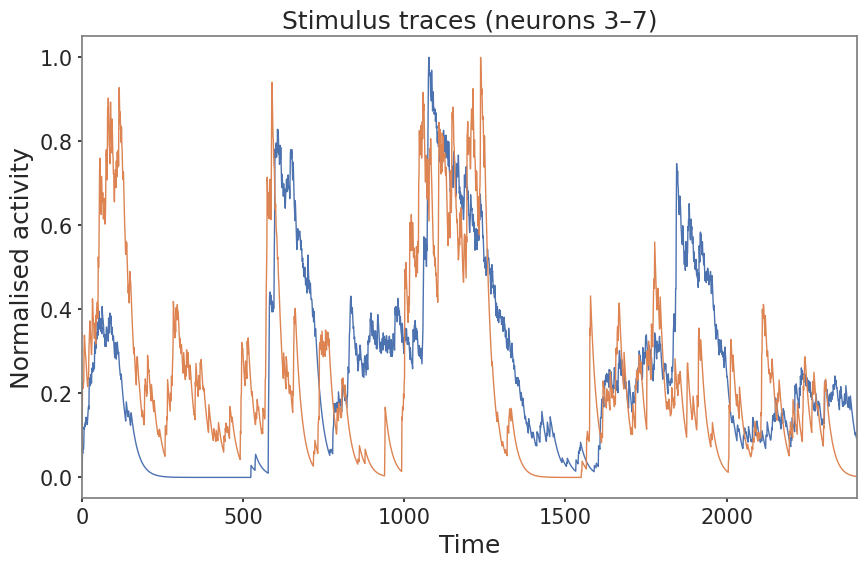

In [31]:
X = minmax_scale(data_fig1_stim_artifact[:, :stim_offset], axis=1)
# X=data_fig1_stim_artifact
plt.figure(figsize=(10, 6))
for i in range(3, 5):  # Python is exclusive at the top
    plt.plot(X[i, :], linewidth=1)

plt.xlim(0, stim_offset)
plt.xlabel("Time")
plt.ylabel("Normalised activity")
plt.title("Stimulus traces (neurons 3–7)")
plt.show()

# 🧪 Full Workflow: G28 Stress (Figure 1)

This is a example restraint stress trial for figure 1 from animal G28.

In [32]:
# Load and transpose the data
data_fig1_stress = pd.read_csv(stress_fig1_csv_fname).T

# Clean up row labels
data_fig1_stress.index = data_fig1_stress.index.str.strip()

# Preview the last 6 cells
data_fig1_stress.tail(5)  # You can change to .tail(2) for a quicker peek

,0,1,2,3,4,5,6,7,8,9,...,5598,5599,5600,5601,5602,5603,5604,5605,5606,5607
C118,accepted,0,43.50841,41.66243,71.19485,68.17417,65.28166,62.51187,59.8596,118.1,...,1470.904,1408.496,1370.514,1426.161,1435.159,1429.393,1603.41,1535.38,1470.237,1407.857
C119,accepted,0,0,0,3.051758e-05,3.051758e-05,3.051758e-05,16.29219,15.59044,184.5471,...,1415.359,1456.487,1393.753,1424.825,1363.454,1430.636,1545.516,1578.892,1510.885,1445.808
C120,accepted,0,0,-3.051758e-05,-3.051758e-05,-3.051758e-05,42.50839,40.71841,64.25385,109.3918,...,1392.933,1431.68,1445.64,1434.384,1418.948,1386.784,1531.457,1466.969,1405.197,1346.025
C121,accepted,0,284.4599,270.7258,257.6548,245.2148,233.3755,222.1078,211.3841,201.1781,...,1027.536,1041.54,1154.067,1098.346,1219.537,1160.656,1104.618,1051.285,1000.527,952.2205
C124,accepted,0,0,-6.103516e-05,45.02893,43.09802,41.24994,103.4197,98.98492,118.9091,...,508.4524,518.7717,539.661,552.7736,529.0699,735.1755,703.6503,673.4768,644.5972,616.9561


### ✂️ Data Slicing for G28 Stress

In [33]:
# Extract signal data (excluding metadata)
cells_traces_fig1_stress_tot = data_fig1_stress.iloc[1:, 1:]

# Get shape info
n_cells_fig1_stress, _ = cells_traces_fig1_stress_tot.shape

# Preview bottom rows
cells_traces_fig1_stress_tot.tail()

,1,2,3,4,5,6,7,8,9,10,...,5598,5599,5600,5601,5602,5603,5604,5605,5606,5607
C118,0,43.50841,41.66243,71.19485,68.17417,65.28166,62.51187,59.8596,118.1,202.4178,...,1470.904,1408.496,1370.514,1426.161,1435.159,1429.393,1603.41,1535.38,1470.237,1407.857
C119,0,0,0,3.051758e-05,3.051758e-05,3.051758e-05,16.29219,15.59044,184.5471,202.6298,...,1415.359,1456.487,1393.753,1424.825,1363.454,1430.636,1545.516,1578.892,1510.885,1445.808
C120,0,0,-3.051758e-05,-3.051758e-05,-3.051758e-05,42.50839,40.71841,64.25385,109.3918,104.7854,...,1392.933,1431.68,1445.64,1434.384,1418.948,1386.784,1531.457,1466.969,1405.197,1346.025
C121,0,284.4599,270.7258,257.6548,245.2148,233.3755,222.1078,211.3841,201.1781,191.465,...,1027.536,1041.54,1154.067,1098.346,1219.537,1160.656,1104.618,1051.285,1000.527,952.2205
C124,0,0,-6.103516e-05,45.02893,43.09802,41.24994,103.4197,98.98492,118.9091,125.1116,...,508.4524,518.7717,539.661,552.7736,529.0699,735.1755,703.6503,673.4768,644.5972,616.9561


In [34]:
# Convert DataFrame to NumPy array for numerical processing
data_fig1_stress_tot = cells_traces_fig1_stress_tot.values.astype(float)

# Slice the data before stimulation onset
data_fig1_stress_1 = data_fig1_stress_tot[:, :stress_onset]

# Slice data during stimulation period
data_fig1_stress_2 = data_fig1_stress_tot[:, stress_onset:stress_offset]

In [35]:
# Rescale pre-stimulation traces using min-max normalisation (row-wise)
normalised_data_fig1_stress_1 = minmax_scale(data_fig1_stress_1, axis=1)

# Rescale stimulation-period traces using min-max normalisation (row-wise)
normalised_data_fig1_stress_2 = minmax_scale(data_fig1_stress_2, axis=1)

### 📈 corrcoef: Standard Pearson Correlation Coefficient

In [36]:
# Compute the correlation matrix for pre-stimulation traces
max_corr_fig1_stress_1 = np.corrcoef(normalised_data_fig1_stress_1, rowvar=True)

# Compute the correlation matrix for stimulation-period traces
max_corr_fig1_stress_2 = np.corrcoef(normalised_data_fig1_stress_2, rowvar=True)

# 🖼️ Figure 1

In [37]:
# Riemannian distances between empirical correlation matrices and a null model
# - Each value reflects how far a real correlation matrix is from a distribution of random matrices
# - Random matrices generated via Metropolis-Hastings sampling
# - Distances are normalised by the mean pairwise distance among sampled matrices

# Control condition: 12 samples across 4 animals (G33–G36)
control_dist = [0.6484, 0.6310, 0.6835, 0.3532, 0.4503, 0.4678, 0.4226, 0.4540, 0.5091, 0.4670, 0.5697, 0.5820]
control_animal = ['G33', 'G33', 'G33', 'G34', 'G34', 'G34', 'G35', 'G35', 'G35', 'G36', 'G36', 'G36']

# Stimulated condition: 20 samples across 6 animals (G7–G9, G28–G29, G37)
stim_dist = [0.8543, 0.8024, 0.8918, 0.7506, 0.8326, 0.8286, 0.7508, 0.7120, 0.8152, 0.7978,
             0.5823, 0.7944, 0.6782, 0.4742, 0.3286, 0.4824, 0.7652, 0.7087, 0.6085, 0.6523]
stim_animal = ['G7', 'G7', 'G8', 'G8', 'G8', 'G8', 'G9', 'G9', 'G9', 'G9',
               'G28', 'G28','G28', 'G29', 'G29', 'G29', 'G37', 'G37', 'G37', 'G37']

# Stress condition: 7 samples across 6 animals (G7–G9, G28–G29, G37)
# - Note: G37 contributes two samples from distinct sessions
stress_dist = [1.001113156, 1.002419683, 0.969890523, 0.7640226, 0.790428686, 0.885770891, 0.810616632]
stress_animal = ['G7', 'G8', 'G9', 'G28', 'G29', 'G37', 'G37']

In [38]:
# AUC values represent integrated response over time windows
# - Each list contains per-sample AUCs for a given condition and time window
# - Negative values may reflect suppression or baseline drift
# - Stress values show large positive outliers, suggesting high activation

# ⏱ 30-second window
AUC_stim_30   = [-3.2941, -0.8233, 1.4743, -1.9491, 2.5396, 1.0696, -0.6789, -0.4772, -0.6625, -2.1106,
                 -2.6996, 10.156, 1.2475, 4.7087, -1.5431, 3.906, 1.4121, -2.2647, -1.1277, -3.9984]
AUC_stress_30 = [3.9668, 4.511, 2.5152, 60.6365, 23.0652, 22.4978, 41.8574]

# ⏱ 60-second window
AUC_stim_60   = [-3.0155, -1.267, 1.6671, -2.3267, 0.952, -0.4225, -2.2116, 1.5772, -0.1854, -1.7976,
                 -1.8799, 14.8400, -2.0294, 4.1857, -0.9583, 1.1032, 0.0982, -2.7538, -0.5514, -3.5729]
AUC_stress_60 = [4.7454, 2.3182, 0.4937, 50.6340, 21.3518, 26.5827, 51.8101]

# ⏱ 90-second window
AUC_stim_90   = [-1.2230, -1.1646, 1.5550, -1.1195, 1.0739, -0.7815, -2.6634, 1.4759, -0.1702, -3.1705,
                 -0.7590, 13.0363, -2.0926, 3.4858, 1.1061, 2.0930, -2.0750, -4.4860, -1.3451, -3.1809]
AUC_stress_90 = [4.2257, 1.6342, -1.6458, 39.6093, 17.7396, 24.2487, 50.9404]

# ⏱ 120-second window
AUC_stim_120   = [-0.6409, -0.7567, 0.7624, -0.5384, 0.7329, -0.8672, 0.0113, 1.1853, 0.6831, -0.7784,
                  -0.8053, 5.1225, -0.5467, 1.7969, -0.0616, 0.3441, -1.2354, -2.4234, -0.7771, -1.499]
AUC_stress_120 = [1.0498, -1.5431, -0.7729, 17.6906, 11.2251, 6.8057, 20.8275]

In [39]:
# --- Helper function to build sub-DataFrame ---
def build_df(animal_list, values, condition):
    df = pd.DataFrame({
        'Animal_id': animal_list,
        'y': values
    })
    # Add condition and compute repeat count per animal
    df['condition'] = condition
    df['repeat'] = df.groupby('Animal_id').cumcount() + 1
    return df[['Animal_id', 'condition', 'repeat', 'y']]


# --- Combine all conditions ---
df_control = build_df(control_animal, control_dist, 'control')
df_stim = build_df(stim_animal, stim_dist, 'stim')
df_stress = build_df(stress_animal, stress_dist, 'stress')

# Merge into one DataFrame
df = pd.concat([df_control,df_stim, df_stress], ignore_index=True)

# Sort for readability
df = df.sort_values(['condition', 'Animal_id', 'repeat']).reset_index(drop=True)

print(df)

   Animal_id condition  repeat         y
0        G33   control       1  0.648400
1        G33   control       2  0.631000
2        G33   control       3  0.683500
3        G34   control       1  0.353200
4        G34   control       2  0.450300
5        G34   control       3  0.467800
6        G35   control       1  0.422600
7        G35   control       2  0.454000
8        G35   control       3  0.509100
9        G36   control       1  0.467000
10       G36   control       2  0.569700
11       G36   control       3  0.582000
12       G28      stim       1  0.582300
13       G28      stim       2  0.794400
14       G28      stim       3  0.678200
15       G29      stim       1  0.474200
16       G29      stim       2  0.328600
17       G29      stim       3  0.482400
18       G37      stim       1  0.765200
19       G37      stim       2  0.708700
20       G37      stim       3  0.608500
21       G37      stim       4  0.652300
22        G7      stim       1  0.854300
23        G7    

In [40]:
# Nested repeats within animal:
#     y ~ condition + (1 | Animal_id) + (1 | Animal_id:repeat)
#     In statsmodels we use a variance component for each (Animal_id:repeat)
m_nested = smf.mixedlm(
    "y ~ condition", df,
    groups=df["Animal_id"],      # (1 | Animal_id)
    re_formula="~1",
    vc_formula={"ar": "0 + C(Animal_id):C(repeat)"}  # (1 | Animal_id:repeat)
).fit(reml=False, method="cg", maxiter=600, disp=False)
print("\n=== Nested model (animal + animal:repeat) ===")
print(m_nested.summary())
pvalues_variable = m_nested.pvalues


=== Nested model (animal + animal:repeat) ===
           Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   y      
No. Observations:    39        Method:               ML     
No. Groups:          10        Scale:                0.0024 
Min. group size:     3         Log-Likelihood:       39.7006
Max. group size:     6         Converged:            Yes    
Mean group size:     3.9                                    
------------------------------------------------------------
                    Coef. Std.Err.   z   P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept           0.520    0.056 9.288 0.000  0.410  0.630
condition[T.stim]   0.184    0.072 2.545 0.011  0.042  0.325
condition[T.stress] 0.365    0.075 4.891 0.000  0.219  0.511
Group Var           0.011    0.163                          
ar Var              0.002    0.049                          



/home/kn356/miniconda_env/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [41]:
p_control_Stim = m_nested.pvalues.get("condition[T.stim]", None)
p_control_Stress = m_nested.pvalues.get("condition[T.stress]", None)
print(p_control_Stim, p_control_Stress)

0.010930667391426296 1.0055671619368434e-06


In [42]:
# Compute p-value for stim vs stress using t-test
# Extract coefficients and standard errors
params = m_nested.params
bse = m_nested.bse

# Coefficients for stim and stress
b_stim = params['condition[T.stim]']
b_stress = params['condition[T.stress]']

# Calculate the difference in coefficients for stress and stim conditions
diff = b_stim - b_stress

# Retrieve the covariance matrix of the fixed effects, which contains the variances and covariances of the estimated coefficients.
cov_matrix = m_nested.cov_params()

# Standard error of the difference
se_diff = np.sqrt(cov_matrix.loc['condition[T.stim]', 'condition[T.stim]'] +
                  cov_matrix.loc['condition[T.stress]', 'condition[T.stress]'] -
                  2 * cov_matrix.loc['condition[T.stim]', 'condition[T.stress]'])

# t-statistic
t_stat = diff / se_diff

# Degrees of freedom (approximation)
df = m_nested.df_resid

# p-value (two-tailed)
p_Stress_Stim = 2 * t.sf(np.abs(t_stat), df)

print(p_Stress_Stim)

1.0861858927992653e-08


In [43]:
mycolors = np.array([
    [140,  81,  10],
    [216, 179, 101],
    [246, 232, 195],
    [199, 234, 229],
    [ 90, 180, 172],
    [  1, 102,  94]
]) / 255.0

colors_ctrl = np.array([
    [166,  97,  26],   # #a6611a
    [223, 194, 125],   # #dfc27d
    [128, 205, 193],   # #80cdc1
    [  1, 133, 113]    # #018571
]) / 255.0

/tmp/ipykernel_332565/2550246778.py:157: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  control_animals = pd.unique(control_animal)
/tmp/ipykernel_332565/2550246778.py:178: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  animals = pd.unique(stim_animal)


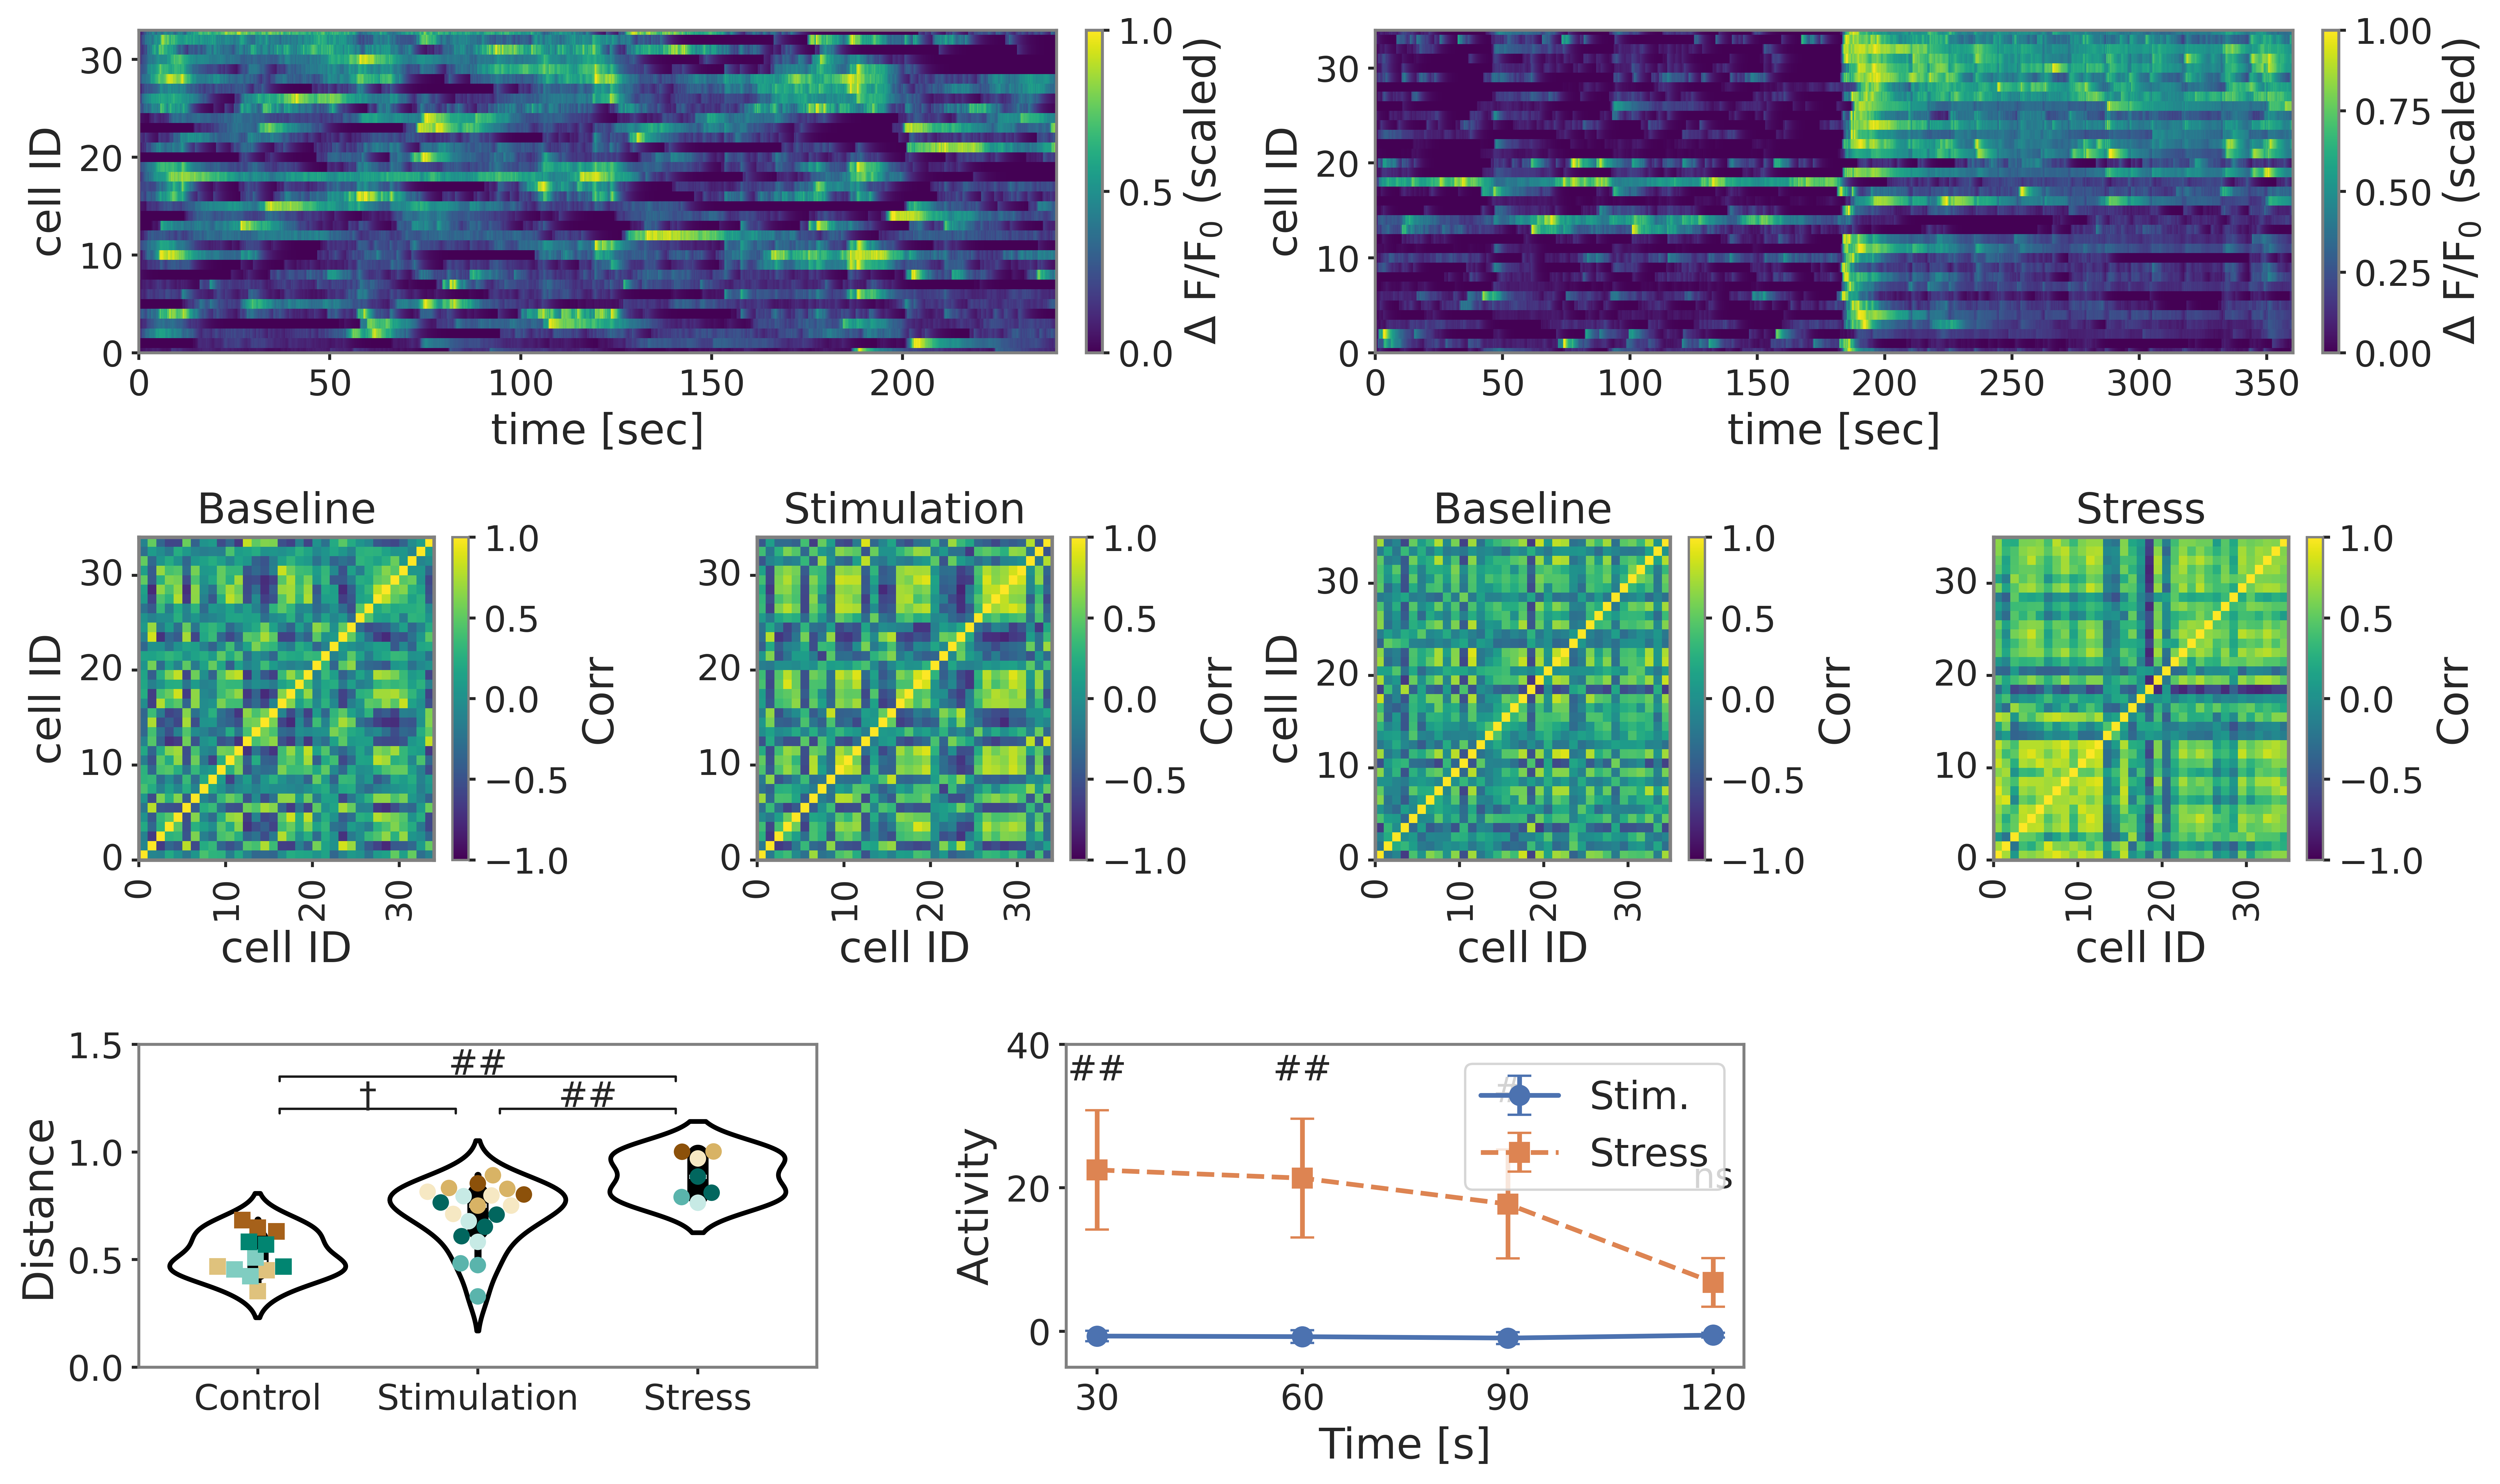

In [44]:
# Create a figure with specific dimensions
fig = plt.figure(figsize=(15, 9), dpi=600)

# Set up the grid layout for subplots
gs = gridspec.GridSpec(3, 8, figure=fig)

# 🔹 Plot 1: Stimulus Data (Baseline)
ax = fig.add_subplot(gs[0:4])
# Normalise stimulus data: z-score across rows (cells), then min-max across columns (time)
stim_data = minmax_scale(data_fig1_stim_tot[:, :stim_offset], axis=1)
plt.imshow(stim_data, cmap="viridis", interpolation='none')

# Set axis limits and ticks for clarity
ax.set_xlim(0, stim_offset)
ax.set_ylim(0, n_cells_fig1_stim-1)
ax.set_xticks(np.arange(0, 2500, 500))
ax.set_xticklabels(np.arange(0, 250, 50))
ax.set_yticks([_ for _ in list(range(n_cells_fig1_stim)) if _ % 10 == 0])
ax.set_yticklabels([_ for _ in list(range(n_cells_fig1_stim)) if _ % 10 == 0])
ax.set_ylabel('cell ID')
ax.set_xlabel('time [sec]')
ax.set_aspect('auto')

# Add colourbar for stimulus data
cmap = plt.get_cmap("viridis")
sm = ScalarMappable(cmap=cmap)
sm.set_clim(vmin=0, vmax=1)
cb = plt.colorbar(cmap=cmap, fraction=0.04, pad=0.03)
cb.set_label('$\Delta$ F$/$F$_0$ (scaled)')

# 🔹 Plot 2: Stress Data (Stress Onset)
ax = fig.add_subplot(gs[4:8])
# Normalise stress data: z-score across rows, then min-max across columns
stress_data = minmax_scale(data_fig1_stress_tot[:, :stress_offset], axis=1)
plt.imshow(stress_data, cmap="viridis", interpolation='none')

# Set axis limits and ticks for clarity
ax.set_xlim(0, stress_offset)
ax.set_ylim(0, n_cells_fig1_stress-1)
ax.set_xticks(np.arange(0, 4000, 500))
ax.set_xticklabels(np.arange(0, 400, 50))
ax.set_yticks([_ for _ in list(range(n_cells_fig1_stress)) if _ % 10 == 0])
ax.set_yticklabels([_ for _ in list(range(n_cells_fig1_stress)) if _ % 10 == 0])
ax.set_ylabel('cell ID')
ax.set_xlabel('time [sec]')
ax.set_aspect('auto')

# Add colourbar for stress data
cmap = plt.get_cmap("viridis")
sm = ScalarMappable(cmap=cmap)
sm.set_clim(vmin=0, vmax=1)
cb = plt.colorbar(cmap=cmap, fraction=0.04, pad=0.03)
cb.set_label('$\Delta$ F$/$F$_0$ (scaled)')

# 🔹 Plot 3: Heatmap for Max Correlation (Baseline)
ax = fig.add_subplot(gs[8:10])
# Heatmap of pairwise correlations during baseline (stim)
sns.heatmap(max_corr_fig1_stim_1, cbar_kws={'label': 'Corr'}, cmap="viridis", vmin=-1, vmax=1)
ax.set_title('Baseline')
ax.set(xlabel='cell ID', ylabel='cell ID')
ax.set_xticks([_ for _ in list(range(n_cells_fig1_stress)) if _ % 10 == 0])
ax.set_xticklabels([_ for _ in list(range(n_cells_fig1_stress)) if _ % 10 == 0])
ax.set_yticks([_ for _ in list(range(n_cells_fig1_stress)) if _ % 10 == 0])
ax.set_yticklabels([_ for _ in list(range(n_cells_fig1_stress)) if _ % 10 == 0])
ax.invert_yaxis()

# Add outline around the whole plot
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_edgecolor('gray')

# Add grey outline around the colourbar
cbar = ax.collections[0].colorbar
cbar.outline.set_visible(True)
cbar.outline.set_edgecolor('grey')
cbar.outline.set_linewidth(1.0)

# 🔹 Plot 4: Heatmap for Max Correlation (Stimulation)
ax = fig.add_subplot(gs[10:12])
# Heatmap of pairwise correlations during stimulation
sns.heatmap(max_corr_fig1_stim_2, cbar_kws={'label': 'Corr'}, cmap="viridis", vmin=-1, vmax=1)
ax.set_title('Stimulation')
ax.set(xlabel='cell ID')
ax.set_xticks([_ for _ in list(range(n_cells_fig1_stress)) if _ % 10 == 0])
ax.set_xticklabels([_ for _ in list(range(n_cells_fig1_stress)) if _ % 10 == 0])
ax.set_yticks([_ for _ in list(range(n_cells_fig1_stress)) if _ % 10 == 0])
ax.set_yticklabels([_ for _ in list(range(n_cells_fig1_stress)) if _ % 10 == 0])
ax.invert_yaxis()

# Add outline around the whole plot
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_edgecolor('gray')

# Add grey outline around the colourbar
cbar = ax.collections[0].colorbar
cbar.outline.set_visible(True)
cbar.outline.set_edgecolor('grey')
cbar.outline.set_linewidth(1.0)

# 🔹 Plot 5: Heatmap for Max Correlation (Stress Baseline)
ax = fig.add_subplot(gs[12:14])
# Heatmap of pairwise correlations during stress baseline
sns.heatmap(max_corr_fig1_stress_1, cbar_kws={'label': 'Corr'}, cmap="viridis", vmin=-1, vmax=1)
ax.set_title('Baseline')
ax.set(xlabel='cell ID', ylabel='cell ID')
ax.set_xticks([_ for _ in list(range(n_cells_fig1_stress)) if _ % 10 == 0])
ax.set_xticklabels([_ for _ in list(range(n_cells_fig1_stress)) if _ % 10 == 0])
ax.set_yticks([_ for _ in list(range(n_cells_fig1_stress)) if _ % 10 == 0])
ax.set_yticklabels([_ for _ in list(range(n_cells_fig1_stress)) if _ % 10 == 0])
ax.invert_yaxis()

# Add outline around the whole plot
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_edgecolor('gray')

# Add grey outline around the colourbar
cbar = ax.collections[0].colorbar
cbar.outline.set_visible(True)
cbar.outline.set_edgecolor('grey')
cbar.outline.set_linewidth(1.0)

# 🔹 Plot 6: Heatmap for Max Correlation (Stress)
ax = fig.add_subplot(gs[14:16])
# Heatmap of pairwise correlations during stress period
sns.heatmap(max_corr_fig1_stress_2, cbar_kws={'label': 'Corr'}, cmap="viridis", vmin=-1, vmax=1)
ax.set_title('Stress')
ax.set(xlabel='cell ID')
ax.set_xticks([_ for _ in list(range(n_cells_fig1_stress)) if _ % 10 == 0])
ax.set_xticklabels([_ for _ in list(range(n_cells_fig1_stress)) if _ % 10 == 0])
ax.set_yticks([_ for _ in list(range(n_cells_fig1_stress)) if _ % 10 == 0])
ax.set_yticklabels([_ for _ in list(range(n_cells_fig1_stress)) if _ % 10 == 0])
ax.invert_yaxis()

# Add outline around the whole plot
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_edgecolor('gray')

# Add grey outline around the colourbar
cbar = ax.collections[0].colorbar
cbar.outline.set_visible(True)
cbar.outline.set_edgecolor('grey')
cbar.outline.set_linewidth(1.0)

# 🔹 Plot 7: Swarm plot for stimulation p-values
colour_list = ['blue', 'red', 'green', 'orange', 'purple', 'brown']
ax = fig.add_subplot(gs[16:19])
# Violin + swarm plot for control condition
cc1 = control_dist

control_animals = pd.unique(control_animal)
control_palette = dict(zip(
    control_animals,
    colors_ctrl[:len(control_animals)]
))

df = pd.DataFrame(dict(x=np.repeat([0], len(cc1)), y=cc1, c=control_animal))
sns.violinplot(x="x", y="y", data=df, order=['0','1','2'], fill=False, color='black')
sns.swarmplot(
    x="x",
    y="y",
    hue="c",
    data=df,
    palette=control_palette,
    size=7,
    marker='s',
    legend=False
)

# Violin + swarm plot for stimulation condition

animals = pd.unique(stim_animal)
palette = dict(zip(animals, mycolors))

cc2 = stim_dist

df = pd.DataFrame(dict(x=np.repeat([1], len(cc2)), y=cc2, c=stim_animal))
sns.violinplot(x="x", y="y", data=df, order=['0','1','2'], fill=False, color='black')
sns.swarmplot(
    x="x",
    y="y",
    hue="c",
    data=df,
    palette=palette,
    order=[1],   # x is numeric and always 1
    size=7,
    legend=False
)

# Violin + swarm plot for stress condition
cc3 = stress_dist
df = pd.DataFrame(dict(
    x=np.repeat(2, len(cc3)),
    y=cc3,
    c=stress_animal
))
sns.violinplot(x="x", y="y", data=df, order=['0','1','2'], fill=False, color='black')
sns.swarmplot(
    x="x",
    y="y",
    hue="c",
    data=df,
    palette=palette,
    order=[2],
    size=7,
    legend=False
)

# Add statistical annotations between groups
# Control vs Stim
ax.plot([0.1, 0.9], [1.2, 1.2], 'k-', lw=1)
ax.plot([0.1, 0.1], [1.2, 1.18], 'k-', lw=1)
ax.plot([0.9, 0.9], [1.2, 1.18], 'k-', lw=1)
_, kruskal_p_value = kruskal(control_dist, stim_dist)
ax.annotate(pval_to_star(p_control_Stim), (1/2, 1.21), ha='center')

# Stim vs Stress
ax.plot([1.1, 1.9], [1.2, 1.2], 'k-', lw=1)
ax.plot([1.1, 1.1], [1.2, 1.18], 'k-', lw=1)
ax.plot([1.9, 1.9], [1.2, 1.18], 'k-', lw=1)
_, kruskal_p_value = kruskal(stress_dist, stim_dist)
ax.annotate(pval_to_star(p_Stress_Stim), (3/2, 1.21), ha='center')

# Control vs Stress
ax.plot([0.1, 1.9], [1.35, 1.35], 'k-', lw=1)
ax.plot([0.1, 0.1], [1.35, 1.33], 'k-', lw=1)
ax.plot([1.9, 1.9], [1.35, 1.33], 'k-', lw=1)
_, kruskal_p_value = kruskal(control_dist, stress_dist)
ax.annotate(pval_to_star(p_control_Stress), (1, 1.36), ha='center')

# Final axis settings
ax.set_ylim(0.0, 1.5)
ax.set_xlabel('')
ax.set_ylabel('Distance')
ax.set_xticks(range(3), labels=['Control', 'Stimulation', 'Stress'])

# 🔹 Plot 8: Swarm plot for stress p-values
ax = fig.add_subplot(gs[19:22])

# Time windows used for AUC calculation
time_points = [30, 60, 90, 120]

# Grouped AUC data for stim and stress conditions
stim_data = [AUC_stim_30, AUC_stim_60, AUC_stim_90, AUC_stim_120]
stress_data = [AUC_stress_30, AUC_stress_60, AUC_stress_90, AUC_stress_120]

# Compute median and SEM for each time window
stim_medians = [np.median(d) for d in stim_data]
stim_sem = [np.std(d, ddof=1) / np.sqrt(len(d)) for d in stim_data]

stress_medians = [np.median(d) for d in stress_data]
stress_sem = [np.std(d, ddof=1) / np.sqrt(len(d)) for d in stress_data]

# Create a DataFrame for plotting
df = pd.DataFrame({
    'Time': time_points,
    'Stim_Median': stim_medians,
    'Stim_SEM': stim_sem,
    'Stress_Median': stress_medians,
    'Stress_SEM': stress_sem
})

# Plot median ± SEM for stimulation
ax.errorbar(df['Time'], df['Stim_Median'], yerr=df['Stim_SEM'],
            label='Stim', marker='o', capsize=5, linestyle='-')

# Plot median ± SEM for stress
ax.errorbar(df['Time'], df['Stress_Median'], yerr=df['Stress_SEM'],
            label='Stress', marker='s', capsize=5, linestyle='--')

# Annotate significance for each time window using Mann-Whitney U test
_, mw_p_value = mannwhitneyu(AUC_stim_30, AUC_stress_30)
ax.annotate(pval_to_star(mw_p_value), (30, 35), ha='center')

_, mw_p_value = mannwhitneyu(AUC_stim_60, AUC_stress_60)
ax.annotate(pval_to_star(mw_p_value), (60, 35), ha='center')

_, mw_p_value = mannwhitneyu(AUC_stim_90, AUC_stress_90)
ax.annotate(pval_to_star(mw_p_value), (90, 32), ha='center')

_, mw_p_value = mannwhitneyu(AUC_stim_120, AUC_stress_120)
ax.annotate(pval_to_star(mw_p_value), (120, 20), ha='center')

# Final axis settings
ax.set_ylim(-5, 40)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Activity')
ax.set_xticks([30, 60, 90, 120])
ax.legend(['Stim.', 'Stress'])

# Adjust layout to prevent overlap and ensure clean spacing
plt.tight_layout()

# Optional: Save figure as SVG for publication-quality output
# plt.savefig('./gdrive/My Drive/Fig1_revised.svg', format='svg', dpi=300)

# Display the figure
fig.savefig("Fig1_revised.svg", format="svg", bbox_inches="tight", dpi=600)
plt.show()

# 🧪 Full Workflow: G28 Stimulation (Figure 2)

An example of data analysis pipline for stimulation experimental setup.

In [45]:
# Load and transpose the data
data_fig2_stim = pd.read_csv(stim_fig2_csv_fname).T

# Clean up row labels
data_fig2_stim.index = data_fig2_stim.index.str.strip()

# Preview the last 6 cells
data_fig2_stim.tail(6)

,0,1,2,3,4,5,6,7,8,9,...,4296,4297,4298,4299,4300,4301,4302,4303,4304,4305
C088,accepted,0,0,0,76.50677,73.03059,69.71234,66.54487,63.52131,139.8829,...,1074.834,1223.433,1167.845,1114.782,1064.131,1015.78,969.6271,925.5707,883.5162,843.3723
C094,accepted,0,0,6.103516e-05,0,6.103516e-05,6.103516e-05,6.103516e-05,6.103516e-05,6.103516e-05,...,704.7659,750.5431,708.8228,700.9659,952.5929,1107.16,1075.415,1578.796,1491.036,1408.154
C096,accepted,0,643.9747,1173.457,1472.662,1574.646,1541.89,1470.428,1431.547,1488.959,...,847.2992,979.4389,931.9738,886.809,843.8329,802.9395,764.0279,727.0019,691.7703,658.2461
C103,accepted,0,51.0127,178.9229,170.0222,287.7782,586.1436,556.9858,529.2788,556.7461,...,1755.769,1668.429,1585.433,1506.566,1431.623,1494.466,1420.124,1349.481,1282.351,1218.561
C105,accepted,0,200.9243,191.496,182.5101,173.9458,165.7835,158.0041,150.5898,143.5234,...,1272.222,1212.524,1155.626,1133.084,1079.914,1099.959,1285.939,1225.597,1168.086,1113.274
C107,accepted,0,0,20.12329,116.3702,110.9654,105.8116,100.8972,96.21104,91.74251,...,205.7807,373.305,449.5083,546.0685,592.2088,564.7036,710.1234,934.0911,890.7072,849.3382


## ✂️ Data Slicing for G28 Stimulation

In [46]:
# Extract signal data (excluding metadata)
cells_traces_tot_old = data_fig2_stim.iloc[1:, 1:]

# Get shape info
total_cells_stim, data_stim_length_tot = cells_traces_tot_old.shape

# Preview bottom rows
cells_traces_tot_old.tail()

,1,2,3,4,5,6,7,8,9,10,...,4296,4297,4298,4299,4300,4301,4302,4303,4304,4305
C094,0,0,6.103516e-05,0,6.103516e-05,6.103516e-05,6.103516e-05,6.103516e-05,6.103516e-05,6.103516e-05,...,704.7659,750.5431,708.8228,700.9659,952.5929,1107.16,1075.415,1578.796,1491.036,1408.154
C096,0,643.9747,1173.457,1472.662,1574.646,1541.89,1470.428,1431.547,1488.959,1416.802,...,847.2992,979.4389,931.9738,886.809,843.8329,802.9395,764.0279,727.0019,691.7703,658.2461
C103,0,51.0127,178.9229,170.0222,287.7782,586.1436,556.9858,529.2788,556.7461,581.2056,...,1755.769,1668.429,1585.433,1506.566,1431.623,1494.466,1420.124,1349.481,1282.351,1218.561
C105,0,200.9243,191.496,182.5101,173.9458,165.7835,158.0041,150.5898,143.5234,136.7886,...,1272.222,1212.524,1155.626,1133.084,1079.914,1099.959,1285.939,1225.597,1168.086,1113.274
C107,0,0,20.12329,116.3702,110.9654,105.8116,100.8972,96.21104,91.74251,87.48152,...,205.7807,373.305,449.5083,546.0685,592.2088,564.7036,710.1234,934.0911,890.7072,849.3382


In [47]:
# Extract time axis from first row (excluding first column)
ts_stim_tot = np.asarray(data_fig2_stim.iloc[0, 1:], dtype=float)

# Time between frames (first timestamp is 0)
sec_per_frame = ts_stim_tot[1]

# Sampling frequency (Hz)
fs = 1 / sec_per_frame

In [48]:
# Convert fluorescence traces to NumPy array
data_stim_artifact = np.asarray(cells_traces_tot_old, dtype=float)

## 🔍 Finding UCN3 Cells

### 🌀 1. Power Spectral Density (PSD) Filtering

In [49]:
# Define the stimulus frequency and initialise a list to store labels of removed cells based on PSD threshold
stimulus_freq = 0.1  # Stimulus frequency in Hz
labels_removed_PSD = []  # List to store indices of cells with high PSD at stimulus frequency

# Loop through each cell trace to assess frequency-domain response
for i in range(total_cells_stim):
    # Extract stimulation-period trace for cell i
    trace_segment = data_stim_artifact[i, stim_onset:stim_offset]

    # Compute power spectral density using periodogram
    freq, Pxx_den = periodogram(trace_segment, fs=fs)

    # Normalise PSD to its peak value for comparability
    Pxx_den /= np.max(Pxx_den)

    # Identify index corresponding to stimulus frequency
    stimulus_freq_idx = round(stimulus_freq * (stim_offset - stim_onset) / fs)

    # Thresholding: retain cells with strong PSD at stimulus frequency
    if Pxx_den[stimulus_freq_idx] > PSD_thr:
        labels_removed_PSD.append(i)

# Output: indices of cells flagged for removal based on PSD criterion
print("Indices of cells removed based on PSD threshold:", labels_removed_PSD)

Indices of cells removed based on PSD threshold: [13, 18, 25, 33]


In [50]:
#   Create binary mask to flag artifact-affected cells
# - 0: cell identified as artifact (high PSD at stimulus frequency)
# - 1: cell retained for further analysis
labels_artifact = np.asarray([
    0 if cell in labels_removed_PSD else 1
    for cell in range(total_cells_stim)
])

# Optional: Print the binary mask to verify which cells were flagged
# 0 = artifact (failed PSD threshold), 1 = valid (passed PSD threshold)
print(labels_artifact)

[1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1
 1 1 1 1 1 1 1 1 1 1]


### 🔢 2. K-Means Clustering

In [51]:
# Apply scikit-learn K-means clustering to sort activity traces

# Step 1: Normalise the activity data across time (columns) to ensure fair clustering
scaled_data = scale(data_stim_artifact[:, stim_onset:stim_offset], axis=0)

# Step 2: Set the number of clusters (2 groups: responsive vs non-responsive)
Ks = 2

# Step 3: Initialise and run K-means clustering
# - random_state ensures reproducibility
# - n_init = 10 means the algorithm runs 10 times with different centroid seeds
# - max_iter = 100 limits the number of iterations per run
kmeans = KMeans(n_clusters=Ks, random_state=11111, n_init=10, max_iter=100)

# Step 4: Fit the model to the scaled data and assign cluster labels to each cell
labels_artifact_KM = kmeans.fit_predict(scaled_data)

# Step 5: Sort cell indices based on their assigned cluster labels
# This helps organise or visualise cells by their activity patterns
i_labels_artifact = np.argsort(labels_artifact_KM)

# Step 6: Display the sorted indices for inspection or downstream analysis
print(f"Sorted indices of cells by cluster ID:\n{i_labels_artifact}")

Sorted indices of cells by cluster ID:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 19 20 22 21 23 24
 30 26 27 28 31 29 34 32 44 41 35 36 38 37 39 40 46 45 42 43 25 18 33]


In [52]:
# Determine which cluster to remove based on relative size

# Step 1: Count the number of cells in each cluster
size_cluster_0 = np.sum(labels_artifact_KM == 0)
size_cluster_1 = np.sum(labels_artifact_KM == 1)

# Step 2: Compare cluster sizes to identify the smaller one
# The assumption here is that the smaller cluster likely represents artifacts or noise
if size_cluster_0 < size_cluster_1:
    cluster_removed = 0  # Smaller cluster is flagged for removal
    cluster_kept = 1     # Larger cluster is retained
    print("Cluster #0 (smaller) is removed.")
elif size_cluster_1 < size_cluster_0:
    cluster_removed = 1
    cluster_kept = 0
    print("Cluster #1 (smaller) is removed.")
else:
    # Edge case: one cluster has zero members, so no valid removal decision
    print("Clusters are equal in size — no removal applied.")

Cluster #1 (smaller) is removed.


In [53]:
# Update artifact labels based on K-means clustering results

# Step 1: Check if the cluster marked for removal contains any cells
if np.any(labels_artifact_KM == cluster_removed):
    # Step 2: Iterate through all cells
    for i in range(len(data_stim_artifact)):
        # Only update cells that were previously marked as valid (1)
        # and now belong to the cluster flagged for removal
        if labels_artifact[i] == 1 and labels_artifact_KM[i] == cluster_removed:
            labels_artifact[i] = 0  # Mark as artifact

# Step 3: Explicitly define which cluster was removed and which was kept
cluster_removed = 0
cluster_kept = 1

# Step 4: Extract indices of cells now marked as artifacts
labels_removed = np.where(labels_artifact == cluster_removed)[0]

# Optional: print summary for verification
print(f"Number of (UCN) cells removed: {len(labels_removed)}")
print(f"Indices of removed cells: {labels_removed}")

Number of (UCN) cells removed: 4
Indices of removed cells: [13 18 25 33]


In [54]:
# Remove resonated (artifact) cells from fluorescence intensity traces

# Step 1: Get the row labels (e.g., cell IDs) corresponding to removed indices
removed_row_labels = cells_traces_tot_old.index[labels_removed]

# Step 2: Drop the identified artifact cells from the original DataFrame
# - axis=0 means rows are being removed
# - inplace=False ensures the original DataFrame remains unchanged
cells_traces_stim_tot = cells_traces_tot_old.drop(
    index=removed_row_labels, axis=0, inplace=False
)

# Step 3: Count the number of remaining (valid) cells after removal
n_cells_stim = len(cells_traces_stim_tot)

# Optional: print summary
print(f"Number of GABA cells retained after artifact removal: {n_cells_stim}")

Number of GABA cells retained after artifact removal: 43


## Minmax Scaling over each trace

In [55]:
# Convert fluorescence traces to NumPy array (float)
data_stim_tot = np.asarray(cells_traces_stim_tot, dtype=float)

# Apply Min-Max scaling to each trace individually
# - Rescales each cell's activity to [0, 1] across its full time course
normalised_data_stim_tot = minmax_scale(data_stim_tot, axis=1)

## ⚡️ **G28 Stimulation**

Hereafter, I only focus on the data while the stimulation is applied at 2 minutes after starting recording with 0.1 Hz (5 s on followed by 5 s off).

### ✂️ Data Slicing

In [56]:
# Slice fluorescence data to isolate stimulation period
cells_traces_stim_2 = cells_traces_stim_tot.iloc[:, stim_onset:stim_offset]

# Min-max normalised fluorescence during stimulation
normalised_data_stim_2 = normalised_data_stim_tot[:, stim_onset:stim_offset]

# Update stimulation-period length
data_stim_length_2 = cells_traces_stim_2.shape[1]

# Optional: preview first few traces during stimulation
cells_traces_stim_2.head()

,1205,1206,1207,1208,1209,1210,1211,1212,1213,1214,...,2395,2396,2397,2398,2399,2400,2401,2402,2403,2404
C000,9.610781,9.109393,8.634162,8.183723,7.756784,7.352118,6.968563,6.605018,6.260438,212.7549,...,681.997,646.4177,701.6332,690.388,754.6913,838.5499,794.8033,810.6327,778.7357,791.5369
C001,51.14697,48.14611,45.32131,42.66225,40.15919,37.803,35.58505,33.49723,31.5319,29.68188,...,510.3558,480.4125,452.226,425.6933,437.5678,463.4797,436.2867,410.6892,386.5935,363.9115
C002,161.9082,152.0339,142.7617,134.0551,125.8794,118.2023,110.9935,104.2243,97.86794,91.89923,...,347.8694,326.6537,306.732,288.0252,270.4593,253.9647,238.4761,223.9321,210.275,197.4509
C003,96.05541,91.40376,86.97738,82.76535,78.75729,74.94334,71.31407,67.86057,64.5743,61.44717,...,593.0775,645.7643,792.8328,783.1747,785.0201,747.0042,836.3228,795.8224,976.7411,1058.116
C004,525.4421,667.9557,634.5085,602.7361,641.6688,711.6713,676.0351,642.1833,718.572,840.8339,...,454.1858,488.2891,598.3847,568.4211,586.6035,557.2299,551.1138,658.4133,728.7188,740.4006


In [57]:
# Create time axis for stimulation period
# - Ensures alignment with sliced fluorescence data
ts_stim_2 = ts_stim_tot[stim_onset:stim_offset]

In [58]:
# Convert stimulation-period fluorescence data to NumPy array (float)
# - Enables numerical operations like clustering, filtering, or plotting
data_stim_2 = np.asarray(cells_traces_stim_2, dtype=float)

### Clustering

#### 🌲 Hierarchical (corrcoef)

In [59]:
# Compute pairwise correlation-based distances
# - Distance metric: 1 - Pearson correlation coefficient
# - pdist returns a condensed distance matrix (n*(n-1)/2 elements)
dist_corr_stim_2 = pdist(normalised_data_stim_2,
                         lambda x, y: 1 - np.corrcoef(x, y)[0, 1])

In [60]:
# Convert condensed distance matrix to square form
# - Required for AgglomerativeClustering with 'precomputed' metric
dist_matrix = squareform(dist_corr_stim_2)

# Apply hierarchical clustering to sort activity traces
# - AgglomerativeClustering performs hierarchical clustering.
# - `n_clusters=Ks_2` specifies the number of clusters.
# - `metric='precomputed'` indicates that the distance matrix has already been computed.
# - `linkage='average'` uses the average linkage criterion for merging clusters.
# - `compute_distances=True` ensures that pairwise distances are retained.
ac = AgglomerativeClustering(
    n_clusters=Ks_2,
    metric='precomputed',
    linkage='average',
    compute_distances=True
).fit(dist_matrix)

# Retrieve the cluster labels assigned to each trace
labels_hier_stim_2 = ac.labels_

In [61]:
# Compute pairwise Pearson correlation matrix for stimulation data
# - Avoids redundant diagonal comparisons
# - Uses z-scored traces for consistency
max_corr_stim_2 = np.zeros((n_cells_stim, n_cells_stim))

for i in range(n_cells_stim):
    for j in range(i + 1, n_cells_stim):  # Upper triangle only
        trace_i = scale(normalised_data_stim_2[i, :])
        trace_j = scale(normalised_data_stim_2[j, :])
        corr = np.corrcoef(trace_i, trace_j)[0, 1]
        max_corr_stim_2[i, j] = corr
        max_corr_stim_2[j, i] = corr  # Symmetric assignment

In [62]:
from sklearn.metrics import silhouette_score

# Evaluate clustering quality using silhouette score
# - Measures how well each trace fits within its assigned cluster
# - Higher scores indicate better-defined clusters
sil_score = silhouette_score(
    squareform(dist_corr_stim_2),  # Full distance matrix
    labels_hier_stim_2,            # Cluster labels
    metric="precomputed"           # Use provided distances
)

# Display the silhouette score
print(f'Silhouette score: {sil_score:.3f}')

Silhouette score: 0.502


#### 🔢 K-means (corrcoef)

In [63]:
# Apply scikit-learn K-means clustering to the SLxCorr distance matrix
# Fix the random seed for reproducibility and set the number of clusters (Ks_2)
km = KMeans(n_clusters=Ks_2, random_state=11112, n_init=10, max_iter=100)

# Fit the model on the squared form of the SLxCorr distance matrix
km.fit(squareform(dist_corr_stim_2))

# Get the labels for the clusters assigned to each cell
labels_corr_stim_2 = km.labels_

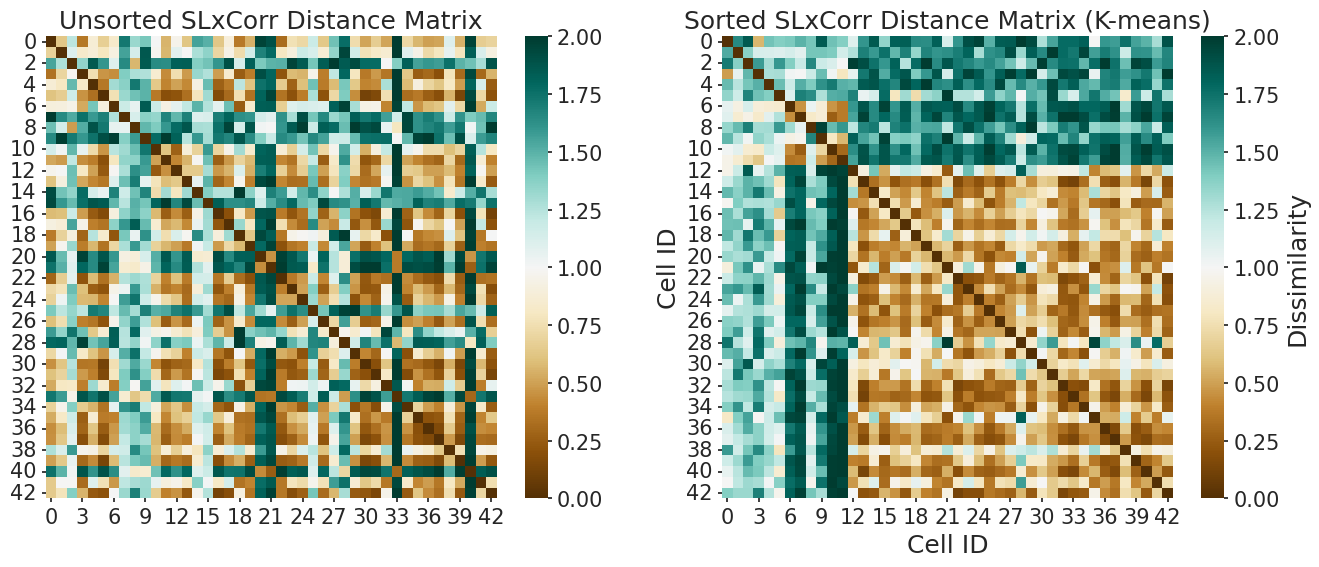

In [64]:
# Plotting the unsorted and sorted (SLxCorr, K-means) distance matrices
plt.figure(figsize=(16, 6))

# Subplot 1: Unsorted SLxCorr distance matrix
plt.subplot(1, 2, 1)
sns.heatmap(2 * minmax_scale(squareform(dist_corr_stim_2),axis=1), cmap='BrBG')
plt.title('Unsorted SLxCorr Distance Matrix')

# Subplot 2: Sorted SLxCorr distance matrix based on K-means labels
plt.subplot(1, 2, 2)
# Sorting the SLxCorr distance matrix based on the K-means cluster labels
idx = np.argsort(labels_corr_stim_2)  # Sort indices by K-means labels
sorted_cov_dist = squareform(dist_corr_stim_2)[idx, :][:, idx]  # Apply sorting
ax = sns.heatmap(2 * minmax_scale(sorted_cov_dist,axis=1),
                 cmap='BrBG', cbar_kws={'label': 'Dissimilarity'})
ax.set(xlabel='Cell ID', ylabel='Cell ID')
plt.title('Sorted SLxCorr Distance Matrix (K-means)')

# Show the plot
plt.show()

# 🧪 Full Workflow: G9 Stress (Figure 2)

An example of data analysis pipline for restraint stress experimental setup.

In [65]:
# Load stress dataset from CSV and transpose it
# - Transposition makes each row represent a cell (e.g., for time-series or feature vectors)
data_fig2_stress = pd.read_csv(stress_fig2_csv_fname).T

# Clean up cell ID labels by stripping whitespace
# - Ensures consistent indexing and avoids matching issues
data_fig2_stress.index = data_fig2_stress.index.str.strip()

# Display the last few rows of the transposed dataset
# - Useful for inspecting cell-level data or verifying formatting
data_fig2_stress.tail()

,0,1,2,3,4,5,6,7,8,9,...,6435,6436,6437,6438,6439,6440,6441,6442,6443,6444
C109,accepted,0,95.10193,124.8623,165.0189,158.134,206.9987,259.3236,288.9745,295.3506,...,1584.121,1543.994,1566.582,1566.807,1648.355,1579.582,1513.679,1450.525,1390.006,1332.012
C111,accepted,0,80.1488,116.3439,153.48,197.7316,189.1638,218.9006,280.8517,315.9242,...,962.8788,1009.117,981.3885,938.8648,916.3129,1065.268,1019.11,974.9519,932.7072,892.2928
C112,accepted,0,35.65594,83.49625,79.75183,143.3132,136.8863,130.7477,124.8842,182.0726,...,1289.253,1416.734,1353.2,1292.516,1234.552,1179.189,1126.308,1075.798,1027.554,981.4733
C114,accepted,0,78.29032,112.5898,106.9316,244.0014,231.7393,364.0249,378.1245,405.894,...,906.4796,931.878,998.7589,1015.428,1154.258,1096.252,1041.16,988.8375,939.1442,891.9481
C117,accepted,0,205.761,281.3857,449.4968,579.1699,553.998,630.3789,739.1033,859.9053,...,2573.038,2617.881,2542.832,2569.154,2552.073,2543.887,2653.753,2538.416,2428.092,2322.563


## ✂️ Data Slicing

In [66]:
# Extract fluorescence intensity traces from deconvoluted stress data
# - Skip first row (likely metadata or time vector)
# - Skip first column (likely cell labels or non-numeric info)
cells_traces_stress_tot = data_fig2_stress.iloc[1:, 1:]

# Determine dataset dimensions
# - n_cells_stress: number of cells (rows)
# - data_stress_length_tot: number of time points or features (columns)
n_cells_stress, data_stress_length_tot = cells_traces_stress_tot.shape

# Preview the last few rows of the fluorescence intensity matrix
# - Each row = one cell's trace
# - Each column = one time point or feature
cells_traces_stress_tot.tail()

,1,2,3,4,5,6,7,8,9,10,...,6435,6436,6437,6438,6439,6440,6441,6442,6443,6444
C109,0,95.10193,124.8623,165.0189,158.134,206.9987,259.3236,288.9745,295.3506,442.175,...,1584.121,1543.994,1566.582,1566.807,1648.355,1579.582,1513.679,1450.525,1390.006,1332.012
C111,0,80.1488,116.3439,153.48,197.7316,189.1638,218.9006,280.8517,315.9242,323.5248,...,962.8788,1009.117,981.3885,938.8648,916.3129,1065.268,1019.11,974.9519,932.7072,892.2928
C112,0,35.65594,83.49625,79.75183,143.3132,136.8863,130.7477,124.8842,182.0726,173.9075,...,1289.253,1416.734,1353.2,1292.516,1234.552,1179.189,1126.308,1075.798,1027.554,981.4733
C114,0,78.29032,112.5898,106.9316,244.0014,231.7393,364.0249,378.1245,405.894,385.4961,...,906.4796,931.878,998.7589,1015.428,1154.258,1096.252,1041.16,988.8375,939.1442,891.9481
C117,0,205.761,281.3857,449.4968,579.1699,553.998,630.3789,739.1033,859.9053,997.552,...,2573.038,2617.881,2542.832,2569.154,2552.073,2543.887,2653.753,2538.416,2428.092,2322.563


In [67]:
# Extract time axis from the first row (excluding first column)
# - Assumes first row contains timestamps
# - Converts to NumPy array of floats for numerical operations
ts_stress_tot = np.asarray(data_fig2_stress.iloc[0, 1:], dtype=float)

# Determine time per frame (seconds)
# - Assumes uniform sampling; uses second timestamp as Δt
sec_per_frame = ts_stress_tot[1]

# Compute sampling frequency (Hz)
# - fs = frames per second = 1 / time per frame
fs = 1 / sec_per_frame

## Minmax Scaling over each trace

In [68]:
# Convert fluorescence intensity data to NumPy array (float)
# - Enables fast numerical operations and compatibility with signal processing tools
# - Each row = one cell's activity trace
# - Each column = one time point
data_stress_tot = np.asarray(cells_traces_stress_tot, dtype=float)

# Normalise each cell's fluorescence trace to [0, 1]
# - axis=1 ensures scaling is done per row (i.e., per cell)
# - Preserves temporal dynamics while removing amplitude bias
normalised_data_stress_tot = minmax_scale(data_stress_tot, axis=1)

## 🔥 **G7 Stress**

Hereafter, I only focus on the data while the stimulation is applied at 2 minutes after starting recording with 0.1 Hz (5 s on followed by 5 s off).

### ✂️ Data Slicing

In [69]:
# Slice fluorescence intensity traces during stimulation period
# - Columns correspond to time points; slicing isolates stress window
cells_traces_stress_2 = cells_traces_stress_tot.iloc[:, stress_onset:stress_offset]

# Slice normalized traces for the same stimulation window
# - Ensures amplitude-independent comparison during stress
normalised_data_stress_2 = normalised_data_stress_tot[:, stress_onset:stress_offset]

# Get number of time points during stimulation
data_stress_length_2 = cells_traces_stress_2.shape[1]

# Preview top rows of sliced raw intensity data
cells_traces_stress_2.head()

,1805,1806,1807,1808,1809,1810,1811,1812,1813,1814,...,3595,3596,3597,3598,3599,3600,3601,3602,3603,3604
C001,564.7203,540.077,516.509,534.2924,510.9768,488.6786,502.2167,523.7151,541.6691,540.3986,...,902.8068,909.7328,937.0206,945.0977,966.5388,924.3607,884.0233,915.3652,875.4203,837.2185
C002,980.4408,937.2857,896.0302,856.5905,906.611,866.7056,828.5567,854.4611,869.4901,914.1444,...,127.7488,122.1258,116.7503,111.6114,106.6987,102.0023,97.51255,93.22044,89.11725,85.19466
C003,5.601141e-05,5.36047e-05,5.130141e-05,4.909709e-05,4.698748e-05,4.496851e-05,4.30363e-05,4.118712e-05,3.941738e-05,3.772369e-05,...,288.625,276.2233,330.7137,316.5036,337.491,322.9896,309.1114,301.1467,288.207,284.8316
C004,1184.398,1164.48,1222.307,1190.472,1240.487,1224.88,1239.839,1254.031,1234.069,1179.39,...,549.6006,695.2413,664.4363,634.9963,606.8607,579.9717,554.2741,529.7151,506.2443,483.8135
C006,194.5789,185.3417,176.543,168.162,160.179,152.5748,145.3317,138.4324,131.8607,125.6009,...,0.0005982646,0.0005698634,0.0005428104,0.0005170418,0.0004924964,0.0004691163,605.5109,624.0441,775.2006,1094.609


In [70]:
# Extract time axis corresponding to stimulation period
ts_stress_2 = ts_stress_tot[stress_onset:stress_offset]

In [71]:
# Convert sliced fluorescence intensity data to NumPy array (float)
data_stress_2 = np.asarray(cells_traces_stress_2.iloc[:, :], dtype=float)

### Clustering

#### 🌲 Hierarchical (corrcoef)

In [72]:
# Compute pairwise Pearson correlation-based distances
# - Each trace is standardized (zero mean, unit variance) across time
# - Distance = 1 - Pearson correlation coefficient
#   → High correlation → small distance
dist_corr_stress_2 = pdist(
    scale(normalised_data_stress_2, axis=1),
    lambda x, y: 1 - np.corrcoef(x, y)[0, 1]
)

# Output is a condensed distance matrix
# - Suitable for clustering, silhouette scoring, or dendrograms

In [73]:
# Apply hierarchical clustering to standardized activity traces
# - Uses precomputed Pearson correlation-based distances
# - Average linkage merges clusters based on mean pairwise distance
ac = AgglomerativeClustering(
    n_clusters=Ks_2,                 # 🔢 Desired number of clusters
    metric='precomputed',            # 📏 Use custom distance matrix
    linkage='average',               # 🔗 Average linkage for merging
    compute_distances=True           # 📐 Retain distance info for dendrograms
).fit(squareform(dist_corr_stress_2))   # 🔄 Convert condensed to square distance matrix

# Extract cluster labels for each cell trace
labels_hier_stress_2 = ac.labels_

# ✅ `labels_hier_stress_2` contains the cluster assignment for each trace

In [74]:
# Initialize symmetric matrix to store pairwise Pearson correlations
# - Shape: (n_cells_stress, n_cells_stress)
# - Diagonal remains zero (self-comparisons skipped)
max_corr_stress_2 = np.zeros((n_cells_stress, n_cells_stress))

# Compute pairwise correlations (upper triangle only)
# - Each trace is standardised (zero mean, unit variance)
# - Matrix is filled symmetrically to avoid redundant computation
for first in range(n_cells_stress):
    for second in range(first + 1, n_cells_stress):
        corr = np.corrcoef(
            scale(normalised_data_stress_2[first, :]),
            scale(normalised_data_stress_2[second, :])
        )[0, 1]
        max_corr_stress_2[first, second] = corr
        max_corr_stress_2[second, first] = corr  # 🔁 Symmetric fill

In [75]:
# Evaluate clustering quality using silhouette score
# - Measures how similar each cell is to its own cluster vs other clusters
# - Uses precomputed Pearson correlation-based distances
sil_score = silhouette_score(
    squareform(dist_corr_stress_2),   # 🔄 Full pairwise distance matrix
    labels_hier_stress_2,            # 🏷️ Cluster labels
    metric="precomputed"             # 📏 Use custom distance metric
)

# Display silhouette score (range: -1 to 1)
# - Higher = better-defined clusters
print(f'Silhouette score: {sil_score:.3f}')

Silhouette score: 0.431


#### 🔢 K-means (corrcoef)

In [76]:
# Note: KMeans typically expects feature vectors, not distance matrices.
# - Applying it to a distance matrix (especially non-Euclidean) may distort clustering.
# - Consider using MDS or t-SNE to embed the distance matrix into feature space first.

# Apply K-means clustering to the SLxCorr distance matrix
# - `random_state` ensures reproducibility
# - `n_init=10` runs the algorithm multiple times to avoid poor local minima
# - `max_iter=100` limits iterations per run
km = KMeans(n_clusters=Ks_2, random_state=11112, n_init=10, max_iter=100)

# Fit the model on the square distance matrix
# - Assumes rows are interpretable as feature vectors (approximate)
km.fit(squareform(dist_corr_stress_2))

# Extract cluster labels for each cell
labels_corr_stress_2 = km.labels_

# 🖼️ Figure 2

In [77]:
# Load hierarchical clustering cell percentage data
# - Each row = one trial
# - Each column = one cluster category (e.g., Cluster 0, Cluster 1, ...)
cell_percentage_hier = pd.read_csv(hier_clustering_cell_perc_fname)

# Preview the bottom rows to inspect structure and completeness
cell_percentage_hier.tail()

,Total # of Cells (All Animals),# of GABA Cells (All Animals),# of Removed Cells (All Animals),All Animals (#1),All Animals (#2),# of GABA Cells (Stimulation),# of Removed Cells (Stimulation),Stimulation (#1),Stimulation (#2),# of GABA Cells (Stress),...,# of GABA Cells (G29),# of Removed Cells (G29),G29 (#1),G29 (#2),# of GABA Cells (G37),# of Removed Cells (G37),G37 (#1),G37 (#2),All Animals (#1).1,All Animals (#2).1
42,63.0,63.0,0.0,23.809524,76.190476,NaN,NaN,NaN,NaN,63.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0,48.0
43,35.0,35.0,0.0,8.571429,91.428571,NaN,NaN,NaN,NaN,35.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,32.0
44,29.0,29.0,0.0,13.793103,86.206897,NaN,NaN,NaN,NaN,29.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,25.0
45,39.0,39.0,0.0,35.897436,64.102564,NaN,NaN,NaN,NaN,39.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.0,25.0
46,31.0,31.0,0.0,19.354839,80.645161,NaN,NaN,NaN,NaN,31.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,25.0


In [78]:
# Extract cluster category labels from column headers
categories_percent_hier = cell_percentage_hier.columns.tolist()

# Extract total number of GABAergic cells across trials
cluster1_cells_allanimals_stim = cell_percentage_hier['Stimulation (#1)']
cluster2_cells_allanimals_stim = cell_percentage_hier['Stimulation (#2)']

cluster1_cells_allanimals_stress = cell_percentage_hier['Stress (#1)']
cluster2_cells_allanimals_stress = cell_percentage_hier['Stress (#2)']

# Remove all the NaNs
cluster1_cells_allanimals_stim = cluster1_cells_allanimals_stim[~np.isnan(cluster1_cells_allanimals_stim)]
cluster2_cells_allanimals_stim = cluster2_cells_allanimals_stim[~np.isnan(cluster2_cells_allanimals_stim)]

cluster1_cells_allanimals_stress = cluster1_cells_allanimals_stress[~np.isnan(cluster1_cells_allanimals_stress)]
cluster2_cells_allanimals_stress = cluster2_cells_allanimals_stress[~np.isnan(cluster2_cells_allanimals_stress)]

print(cluster1_cells_allanimals_stim)


0     42.307692
1     35.294118
5     45.454545
6      7.142857
7     33.333333
8     34.782609
13    25.925926
14     3.703704
15    21.621622
16    32.258065
21     3.448276
22     8.333333
23    20.930233
27    38.461538
28    14.285714
29    41.666667
33    13.636364
34    40.000000
35     8.695652
36    46.666667
Name: Stimulation (#1), dtype: float64


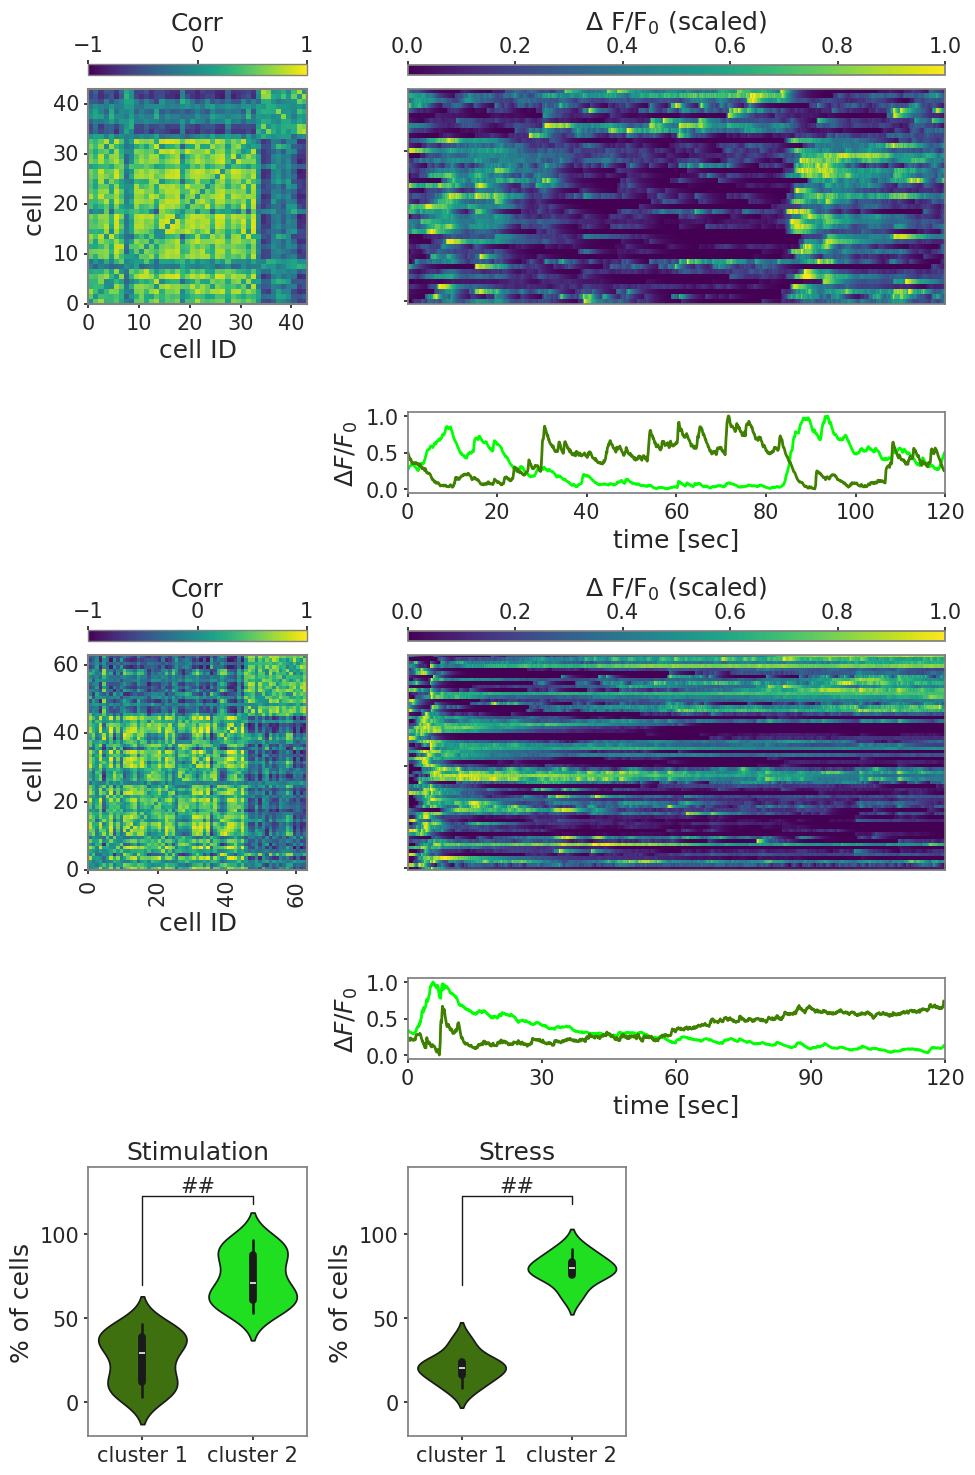

In [79]:
# Set up figure layout
fig = plt.figure(figsize=(10, 15))        # Define overall figure size
gs = gridspec.GridSpec(8, 3, figure=fig)  # Create an 8x3 grid for subplot placement

# Sort cell indices by hierarchical clustering labels (stimulus condition)
idx = np.argsort(labels_hier_stim_2)

# 🔳 Plot 1: Heatmap of pairwise correlations (stimulus condition)
ax = fig.add_subplot(gs[0:2, 0])  # Top-left subplot
ax = sns.heatmap(max_corr_stim_2[idx, :][:, idx],  # Correlation matrix sorted by cluster
                 cbar_kws={'label': 'Corr', 'location': 'top'},  # Colourbar settings
                 cmap="viridis", vmin=-1, vmax=1)  # Colourmap and value range
ax.set(xlabel='cell ID', ylabel='cell ID')  # Axis labels
ax.set_xticks([_ for _ in range(n_cells_stim) if _ % 10 == 0])  # X-axis ticks every 10 cells
ax.set_xticklabels([_ for _ in range(n_cells_stim) if _ % 10 == 0])  # X-axis tick labels
ax.set_yticks([_ for _ in range(n_cells_stim) if _ % 10 == 0])  # Y-axis ticks every 10 cells
ax.set_yticklabels([_ for _ in range(n_cells_stim) if _ % 10 == 0])  # Y-axis tick labels
ax.invert_yaxis()  # Show first cell at top

# Add plot outline
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_edgecolor('gray')

# Add colourbar outline
cbar = ax.collections[0].colorbar
cbar.outline.set_visible(True)
cbar.outline.set_edgecolor('grey')
cbar.outline.set_linewidth(1.0)

# 🔳 Plot 2: Heatmap of normalised fluorescence traces (stimulus condition)
ax = plt.subplot(gs[0:2, 1:3])  # Top-right subplot
im = ax.imshow(minmax_scale(scale(data_stim_2[idx, :], axis=1), axis=1), aspect='auto',
               cmap="viridis", interpolation='none', vmin=0, vmax=1, origin='upper')  # Heatmap of scaled traces
ax.set_xlabel('')
ax.set_xticks([])
ax.set_yticks(range(0, 40, 30))
ax.set_yticklabels([])
ax.invert_yaxis()

# Add colourbar for fluorescence heatmap
cbar = plt.colorbar(im, ax=ax, orientation='horizontal', location='top', aspect=50, pad=0.05)
cbar.set_label('$\Delta$ F$/$F$_0$ (scaled)')

# 🔳 Plot 3: Average traces per cluster (stimulus condition)
ax = plt.subplot(gs[2, 1:3])  # Middle-right subplot
for Ki in range(Ks_2):  # Loop through clusters
    js = np.where(labels_hier_stim_2 == Ki)  # Get cell indices for cluster Ki
    avg = np.mean(np.squeeze(data_stim_2[js, :]), axis=0)  # Average trace
    avg = minmax_scale(avg)  # Normalise trace
    ax.plot(avg, c=GABA_greens[Ki-1])  # Plot with cluster colour
ax.set_xlim(0, 120)
ax.set_xlabel('time [sec]')
ax.set_xticks(range(0, 1400, 200), labels=range(0, 140, 20))
ax.set_ylabel('$\Delta F/F_0$')
ax.set_yticks([0, 0.5, 1])

# Sort cell indices by hierarchical clustering labels (stress condition)
idx = np.argsort(labels_hier_stress_2)

# 🔳 Plot 4: Heatmap of pairwise correlations (stress condition)
ax = fig.add_subplot(gs[3:5, 0])  # Middle-left subplot
ax = sns.heatmap(max_corr_stress_2[idx, :][:, idx],
                 cbar_kws={'label': 'Corr', 'location': 'top'},
                 cmap="viridis", vmin=-1, vmax=1)
ax.set(xlabel='cell ID', ylabel='cell ID')
ax.set_xticks([_ for _ in range(n_cells_stress) if _ % 20 == 0])
ax.set_xticklabels([_ for _ in range(n_cells_stress) if _ % 20 == 0])
ax.set_yticks([_ for _ in range(n_cells_stress) if _ % 20 == 0])
ax.set_yticklabels([_ for _ in range(n_cells_stress) if _ % 20 == 0])
ax.invert_yaxis()

# Add plot outline
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_edgecolor('gray')

# Add colourbar outline
cbar = ax.collections[0].colorbar
cbar.outline.set_visible(True)
cbar.outline.set_edgecolor('grey')
cbar.outline.set_linewidth(1.0)

# 🔳 Plot 5: Heatmap of normalised fluorescence traces (stress condition)
ax = plt.subplot(gs[3:5, 1:3])  # Middle-right subplot
im = ax.imshow(minmax_scale(scale(data_stress_2[idx, :], axis=1), axis=1), aspect='auto',
               cmap="viridis", interpolation='none', vmin=0, vmax=1, origin='upper')
ax.set_xlabel('')
ax.set_xticks([])
ax.set_yticks(range(0, 40, 30))
ax.set_yticklabels([])
ax.invert_yaxis()

# Add colourbar for fluorescence heatmap
cbar = plt.colorbar(im, ax=ax, orientation='horizontal', location='top', aspect=50, pad=0.05)
cbar.set_label('$\Delta$ F$/$F$_0$ (scaled)')

# 🔳 Plot 6: Average traces per cluster (stress condition)
ax = plt.subplot(gs[5, 1:3])  # Bottom-right subplot
for Ki in range(Ks_2):
    js = np.where(labels_hier_stress_2 == Ki)
    avg = np.mean(np.squeeze(data_stress_2[js, :]), axis=0)
    avg = minmax_scale(avg)
    ax.plot(avg, c=GABA_greens[Ki-1])
ax.set_xlim(0, 120)
ax.set_xlabel('time [sec]')
ax.set_xticks(range(0, 1500, 300), labels=range(0, 150, 30))
ax.set_ylabel('$\Delta F/F_0$')
ax.set_yticks([0, 0.5, 1])

# 🔳 Plot 7: Violin plot of cell percentages (stress condition, cluster group A)
ax = plt.subplot(gs[6:8, 0])  # Bottom-left subplot
perc1 = cluster1_cells_allanimals_stim
df = pd.DataFrame(dict(x=np.repeat([0], len(perc1)), y=perc1))
sns.violinplot(x="x", y="y", data=df, order=np.arange(2), inner='box', linecolor='k', color=eff_green)

# perc2 = cell_percentage_hier[categories_percent_hier[8]] / cell_percentage_hier[categories_percent_hier[1]] * 100
perc2 =cluster2_cells_allanimals_stim
df = pd.DataFrame(dict(x=np.repeat([1], len(perc2)), y=perc2))
sns.violinplot(x="x", y="y", data=df, order=np.arange(2), inner='box', linecolor='k', color=inter_green)

ax.set_title(categories_percent_hier[7][:-5])
ax.set_ylim(-20, 140)
ax.set_xlabel('')
ax.set_ylabel('% of cells')
ax.set_xticks(range(2), labels=['cluster 1', 'cluster 2'])
ax.set_yticks(range(0, 150, 50), labels=range(0, 150, 50))

# Statistical tests between cluster groups
ax.plot([0, 1], [123, 123], 'k-', lw=1)
ax.plot([0, 0], [70, 123], 'k-', lw=1)
ax.plot([1, 1], [118, 123], 'k-', lw=1)
MW_p_value, _ = mannwhitneyu(perc1.dropna(), perc2.dropna())
_, KS_p_value = kstest(perc1.dropna(), perc2.dropna())
ax.annotate(pval_to_star(KS_p_value), (0.5, 125), ha='center')

# 🔳 Plot 8: Violin plot of cell percentages (stress condition, cluster group B)
ax = plt.subplot(gs[6:8, 1])  # Bottom-center subplot
perc1 = cluster1_cells_allanimals_stress
df = pd.DataFrame(dict(x=np.repeat([0], len(perc1)), y=perc1))
sns.violinplot(x="x", y="y", data=df, order=np.arange(2), inner='box', linecolor='k', color=eff_green)

# Extract and normalise cell percentages for cluster 2
perc2 = cluster2_cells_allanimals_stress
df = pd.DataFrame(dict(x=np.repeat([1], len(perc2)), y=perc2))
sns.violinplot(x="x", y="y", data=df, order=np.arange(2), inner='box', linecolor='k', color=inter_green)

# Configure plot appearance
ax.set_title(categories_percent_hier[11][:-5])  # Remove suffix from category name
ax.set_ylim(-20, 140)  # Set y-axis limits
ax.set_xlabel('')
ax.set_ylabel('% of cells')
ax.set_xticks(range(2), labels=['cluster 1', 'cluster 2'])
ax.set_yticks(range(0, 150, 50), labels=range(0, 150, 50))

# Statistical tests between cluster groups
ax.plot([0, 1], [123, 123], 'k-', lw=1)  # Horizontal line
ax.plot([0, 0], [70, 123], 'k-', lw=1)   # Left vertical line
ax.plot([1, 1], [118, 123], 'k-', lw=1)  # Right vertical line
MW_p_value, _ = mannwhitneyu(perc1.dropna(), perc2.dropna())  # Mann-Whitney U test
_, KS_p_value = kstest(perc1.dropna(), perc2.dropna())        # Kolmogorov-Smirnov test
ax.annotate(pval_to_star(KS_p_value), (0.5, 125), ha='center')  # Annotate significance

# Optional: Add final layout adjustments and save figure
fig.tight_layout()
plt.savefig('cluster_summary_figure.svg', dpi=700)  # Uncomment to save
plt.show()

# 🖼️ Figure S2 (cluster size)

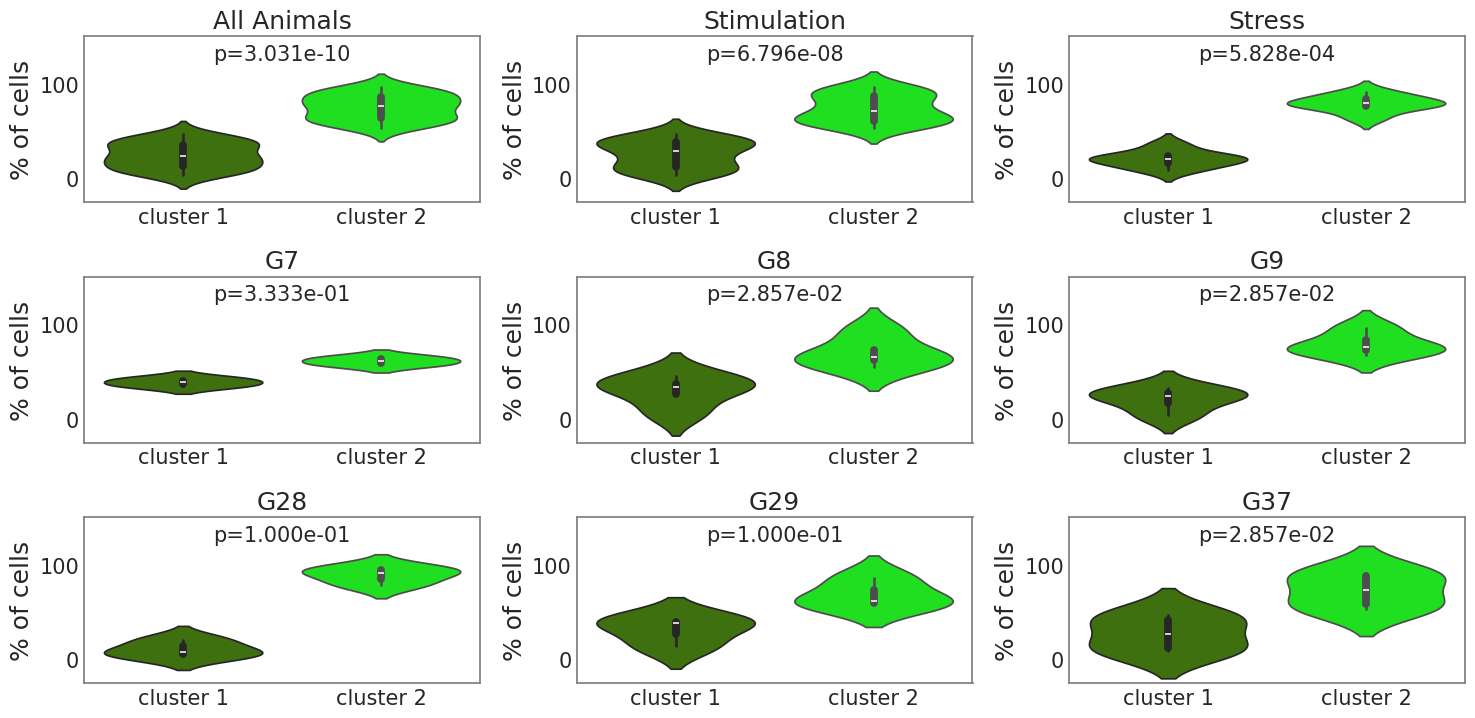

In [80]:
fig = plt.figure(figsize=(15, 12))

# ---------------- Panel 1 (i=0) ----------------
ax = plt.subplot(5, 3, 1)
ax.tick_params(axis='both', length=0)

perc1 = cell_percentage_hier['All Animals (#1)']
perc2 = cell_percentage_hier['All Animals (#2)']


df1 = pd.DataFrame(dict(x=np.repeat([0], len(perc1)), y=perc1))
sns.violinplot(x="x", y="y", data=df1, order=np.arange(2), color=eff_green)


df2 = pd.DataFrame(dict(x=np.repeat([1], len(perc2)), y=perc2))
sns.violinplot(x="x", y="y", data=df2, order=np.arange(2), color=inter_green)

ax.set_title(categories_percent_hier[4*0 + 3][:-5])
ax.set_ylim(-25, 150)
ax.set_xlabel('')
ax.set_ylabel('% of cells')
ax.set_xticks([0, 1], labels=['cluster 1', 'cluster 2'])

_, pval1 = mannwhitneyu(perc1.dropna(), perc2.dropna())
_, pval2 = kstest(perc1.dropna(), perc2.dropna())
ax.annotate(f'p={pval1:0.3e}', (0.5, 125), ha='center')


# ---------------- Panel 2 (i=1) ----------------
ax = plt.subplot(5, 3, 2)
ax.tick_params(axis='both', length=0)

perc1 = cell_percentage_hier['Stimulation (#1)']
perc2 = cell_percentage_hier['Stimulation (#2)']

df1 = pd.DataFrame(dict(x=np.repeat([0], len(perc1)), y=perc1))
sns.violinplot(x="x", y="y", data=df1, order=np.arange(2), color=eff_green)

df2 = pd.DataFrame(dict(x=np.repeat([1], len(perc2)), y=perc2))
sns.violinplot(x="x", y="y", data=df2, order=np.arange(2), color=inter_green)

ax.set_title(categories_percent_hier[4*1 + 3][:-5])
ax.set_ylim(-25, 150)
ax.set_xlabel('')
ax.set_ylabel('% of cells')
ax.set_xticks([0, 1], labels=['cluster 1', 'cluster 2'])

_, pval1 = mannwhitneyu(perc1.dropna(), perc2.dropna())
_, pval2 = kstest(perc1.dropna(), perc2.dropna())
ax.annotate(f'p={pval1:0.3e}', (0.5, 125), ha='center')


# ---------------- Panel 3 (i=2) ----------------
ax = plt.subplot(5, 3, 3)
ax.tick_params(axis='both', length=0)

perc1 = cell_percentage_hier['Stress (#1)']
perc2 = cell_percentage_hier['Stress (#2)']

df1 = pd.DataFrame(dict(x=np.repeat([0], len(perc1)), y=perc1))
sns.violinplot(x="x", y="y", data=df1, order=np.arange(2), color=eff_green)

df2 = pd.DataFrame(dict(x=np.repeat([1], len(perc2)), y=perc2))
sns.violinplot(x="x", y="y", data=df2, order=np.arange(2), color=inter_green)

ax.set_title(categories_percent_hier[4*2 + 3][:-5])
ax.set_ylim(-25, 150)
ax.set_xlabel('')
ax.set_ylabel('% of cells')
ax.set_xticks([0, 1], labels=['cluster 1', 'cluster 2'])

_, pval1 = mannwhitneyu(perc1.dropna(), perc2.dropna())
_, pval2 = kstest(perc1.dropna(), perc2.dropna())
ax.annotate(f'p={pval1:0.3e}', (0.5, 125), ha='center')


# ---------------- Panel 4 (i=3) ----------------
ax = plt.subplot(5, 3, 4)
ax.tick_params(axis='both', length=0)

perc1 = cell_percentage_hier['G7 (#1)']
perc2 = cell_percentage_hier['G7 (#2)']


df1 = pd.DataFrame(dict(x=np.repeat([0], len(perc1)), y=perc1))
sns.violinplot(x="x", y="y", data=df1, order=np.arange(2), color=eff_green)

df2 = pd.DataFrame(dict(x=np.repeat([1], len(perc2)), y=perc2))
sns.violinplot(x="x", y="y", data=df2, order=np.arange(2), color=inter_green)

ax.set_title(categories_percent_hier[4*3 + 3][:-5])
ax.set_ylim(-25, 150)
ax.set_xlabel('')
ax.set_ylabel('% of cells')
ax.set_xticks([0, 1], labels=['cluster 1', 'cluster 2'])

_, pval1 = mannwhitneyu(perc1.dropna(), perc2.dropna())
_, pval2 = kstest(perc1.dropna(), perc2.dropna())
ax.annotate(f'p={pval1:0.3e}', (0.5, 125), ha='center')


# ---------------- Panel 5 (i=4) ----------------
ax = plt.subplot(5, 3, 5)
ax.tick_params(axis='both', length=0)

perc1 = cell_percentage_hier['G8 (#1)']
perc2 = cell_percentage_hier['G8 (#2)']

df1 = pd.DataFrame(dict(x=np.repeat([0], len(perc1)), y=perc1))
sns.violinplot(x="x", y="y", data=df1, order=np.arange(2), color=eff_green)

df2 = pd.DataFrame(dict(x=np.repeat([1], len(perc2)), y=perc2))
sns.violinplot(x="x", y="y", data=df2, order=np.arange(2), color=inter_green)

ax.set_title(categories_percent_hier[4*4 + 3][:-5])
ax.set_ylim(-25, 150)
ax.set_xlabel('')
ax.set_ylabel('% of cells')
ax.set_xticks([0, 1], labels=['cluster 1', 'cluster 2'])

_, pval1 = mannwhitneyu(perc1.dropna(), perc2.dropna())
_, pval2 = kstest(perc1.dropna(), perc2.dropna())
ax.annotate(f'p={pval1:0.3e}', (0.5, 125), ha='center')


# ---------------- Panel 6 (i=5) ----------------
ax = plt.subplot(5, 3, 6)
ax.tick_params(axis='both', length=0)

perc1 = cell_percentage_hier['G9 (#1)']
perc2 = cell_percentage_hier['G9 (#2)']
df1 = pd.DataFrame(dict(x=np.repeat([0], len(perc1)), y=perc1))
sns.violinplot(x="x", y="y", data=df1, order=np.arange(2), color=eff_green)


df2 = pd.DataFrame(dict(x=np.repeat([1], len(perc2)), y=perc2))
sns.violinplot(x="x", y="y", data=df2, order=np.arange(2), color=inter_green)

ax.set_title(categories_percent_hier[4*5 + 3][:-5])
ax.set_ylim(-25, 150)
ax.set_xlabel('')
ax.set_ylabel('% of cells')
ax.set_xticks([0, 1], labels=['cluster 1', 'cluster 2'])

_, pval1 = mannwhitneyu(perc1.dropna(), perc2.dropna())
_, pval2 = kstest(perc1.dropna(), perc2.dropna())
ax.annotate(f'p={pval1:0.3e}', (0.5, 125), ha='center')


# ---------------- Panel 7 (i=6) ----------------
ax = plt.subplot(5, 3, 7)
ax.tick_params(axis='both', length=0)

perc1 = cell_percentage_hier['G28 (#1)']
perc2 = cell_percentage_hier['G28 (#2)']

df1 = pd.DataFrame(dict(x=np.repeat([0], len(perc1)), y=perc1))
sns.violinplot(x="x", y="y", data=df1, order=np.arange(2), color=eff_green)

df2 = pd.DataFrame(dict(x=np.repeat([1], len(perc2)), y=perc2))
sns.violinplot(x="x", y="y", data=df2, order=np.arange(2), color=inter_green)

ax.set_title(categories_percent_hier[4*6 + 3][:-5])
ax.set_ylim(-25, 150)
ax.set_xlabel('')
ax.set_ylabel('% of cells')
ax.set_xticks([0, 1], labels=['cluster 1', 'cluster 2'])

_, pval1 = mannwhitneyu(perc1.dropna(), perc2.dropna())
_, pval2 = kstest(perc1.dropna(), perc2.dropna())
ax.annotate(f'p={pval1:0.3e}', (0.5, 125), ha='center')


# ---------------- Panel 8 (i=7) ----------------
ax = plt.subplot(5, 3, 8)
ax.tick_params(axis='both', length=0)

perc1 = cell_percentage_hier['G29 (#1)']
perc2 = cell_percentage_hier['G29 (#2)']


df1 = pd.DataFrame(dict(x=np.repeat([0], len(perc1)), y=perc1))
sns.violinplot(x="x", y="y", data=df1, order=np.arange(2), color=eff_green)

df2 = pd.DataFrame(dict(x=np.repeat([1], len(perc2)), y=perc2))
sns.violinplot(x="x", y="y", data=df2, order=np.arange(2), color=inter_green)

ax.set_title(categories_percent_hier[4*7 + 3][:-5])
ax.set_ylim(-25, 150)
ax.set_xlabel('')
ax.set_ylabel('% of cells')
ax.set_xticks([0, 1], labels=['cluster 1', 'cluster 2'])

_, pval1 = mannwhitneyu(perc1.dropna(), perc2.dropna())
_, pval2 = kstest(perc1.dropna(), perc2.dropna())
ax.annotate(f'p={pval1:0.3e}', (0.5, 125), ha='center')


# ---------------- Panel 9 (i=8) ----------------
ax = plt.subplot(5, 3, 9)
ax.tick_params(axis='both', length=0)

perc1 = cell_percentage_hier['G37 (#1)']
perc2 = cell_percentage_hier['G37 (#2)']
df1 = pd.DataFrame(dict(x=np.repeat([0], len(perc1)), y=perc1))
sns.violinplot(x="x", y="y", data=df1, order=np.arange(2), color=eff_green)

df2 = pd.DataFrame(dict(x=np.repeat([1], len(perc2)), y=perc2))
sns.violinplot(x="x", y="y", data=df2, order=np.arange(2), color=inter_green)

ax.set_title(categories_percent_hier[4*8 + 3][:-5])
ax.set_ylim(-25, 150)
ax.set_xlabel('')
ax.set_ylabel('% of cells')
ax.set_xticks([0, 1], labels=['cluster 1', 'cluster 2'])

_, pval1 = mannwhitneyu(perc1.dropna(), perc2.dropna())
_, pval2 = kstest(perc1.dropna(), perc2.dropna())
ax.annotate(f'p={pval1:0.3e}', (0.5, 125), ha='center')


fig.tight_layout()
plt.show()


# 🖼️ Figure S3 (corrcoef)

In [81]:
# List of all relevant CSV file paths for UCN-opsin & GABA-GCaMP experiments
all_file_paths = [
    './data/calcium_imaging/UCN3_stimulation/G7 20231110 10hz 222sti.csv',      #1
    './data/calcium_imaging/UCN3_stimulation/G7 20240201 10hz 223sti.csv',      #2
    './data/calcium_imaging/UCN3_stimulation/G8 20240220 10hz 223sti.csv',      #3
    './data/calcium_imaging/UCN3_stimulation/G8 20240301 10hz 223sti.csv',      #4
    './data/calcium_imaging/UCN3_stimulation/G8 20240202 10hz 223sti.csv',      #5
    './data/calcium_imaging/UCN3_stimulation/G8 20231218 10hz 222sti.csv',      #6
    './data/calcium_imaging/UCN3_stimulation/G9 20231218 10hz 222sti.csv',      #7
    './data/calcium_imaging/UCN3_stimulation/G9 20240202 10hz 223sti.csv',      #8
    './data/calcium_imaging/UCN3_stimulation/G9 20240307 10hz 223sti.csv',      #9
    './data/calcium_imaging/UCN3_stimulation/G9 20240228 10hz 223sti.csv',      #10
    './data/calcium_imaging/UCN3_stimulation/G28 20240709 10hz 223sti.csv',     #11
    './data/calcium_imaging/UCN3_stimulation/G28 20240701 10hz 223sti.csv',     #12
    './data/calcium_imaging/UCN3_stimulation/G28 20240704 10hz 223sti.csv',     #13
    './data/calcium_imaging/UCN3_stimulation/G29 20240703 10hz 223sti.csv',     #14
    './data/calcium_imaging/UCN3_stimulation/G29 20240711 10hz 223sti.csv',     #15
    './data/calcium_imaging/UCN3_stimulation/G29 20240705 10hz 223sti.csv',     #16
    './data/calcium_imaging/UCN3_stimulation/G37 10hz 223sti 20240720 A.csv',   #17
    './data/calcium_imaging/UCN3_stimulation/G37 10hz 223sti 20240720 B.csv',   #18
    './data/calcium_imaging/UCN3_stimulation/G37 10hz 223sti 20240721 A.csv',   #19
    './data/calcium_imaging/UCN3_stimulation/G37 10hz 223sti 20240721 B.csv',   #20
    './data/calcium_imaging/UCN3_stimulation/G7 20231218 334restraint.csv',     #21
    './data/calcium_imaging/UCN3_stimulation/G8 20231218 343restraint.csv',     #22
    './data/calcium_imaging/UCN3_stimulation/G9 20231218 334restraint.csv',     #23
    './data/calcium_imaging/restrain_stress/G28 333restraint 20240630.csv',    #24
    './data/calcium_imaging/restrain_stress/G29 333restraint 20240701.csv',    #25
    './data/calcium_imaging/restrain_stress/G37 333restraint 20240719.csv',    #26
    './data/calcium_imaging/restrain_stress/G37 333restraint 20240725.csv',    #27
]


In [82]:
# Selected stimulation files for bootstrapping analysis
# Each entry corresponds to a specific animal and session

boot_file_paths = [
    all_file_paths[1],   # G7 — 2024-02-01 — 223sti
    all_file_paths[5],   # G8 — 2024-03-01 — 223sti
    all_file_paths[8],   # G9 — 2024-03-07 — 223sti
    all_file_paths[12],  # G28 — 2024-07-09 — 223sti
    all_file_paths[15],  # G29 — 2024-07-11 — 223sti
    all_file_paths[17]   # G37 — 2024-07-20 A — 223sti
]

/tmp/ipykernel_332565/3184890293.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([2, 3, 4, '', 2, 3, 4])  # Cluster labels
/tmp/ipykernel_332565/3184890293.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([2, 3, 4, '', 2, 3, 4])  # Cluster labels
/tmp/ipykernel_332565/3184890293.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([2, 3, 4, '', 2, 3, 4])  # Cluster labels
/tmp/ipykernel_332565/3184890293.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([2, 3, 4, '', 2, 3, 4])  # Cluster labels
/tmp/ipykernel_332565/3184890293.py:79: UserWarning: set_ticklabels() should

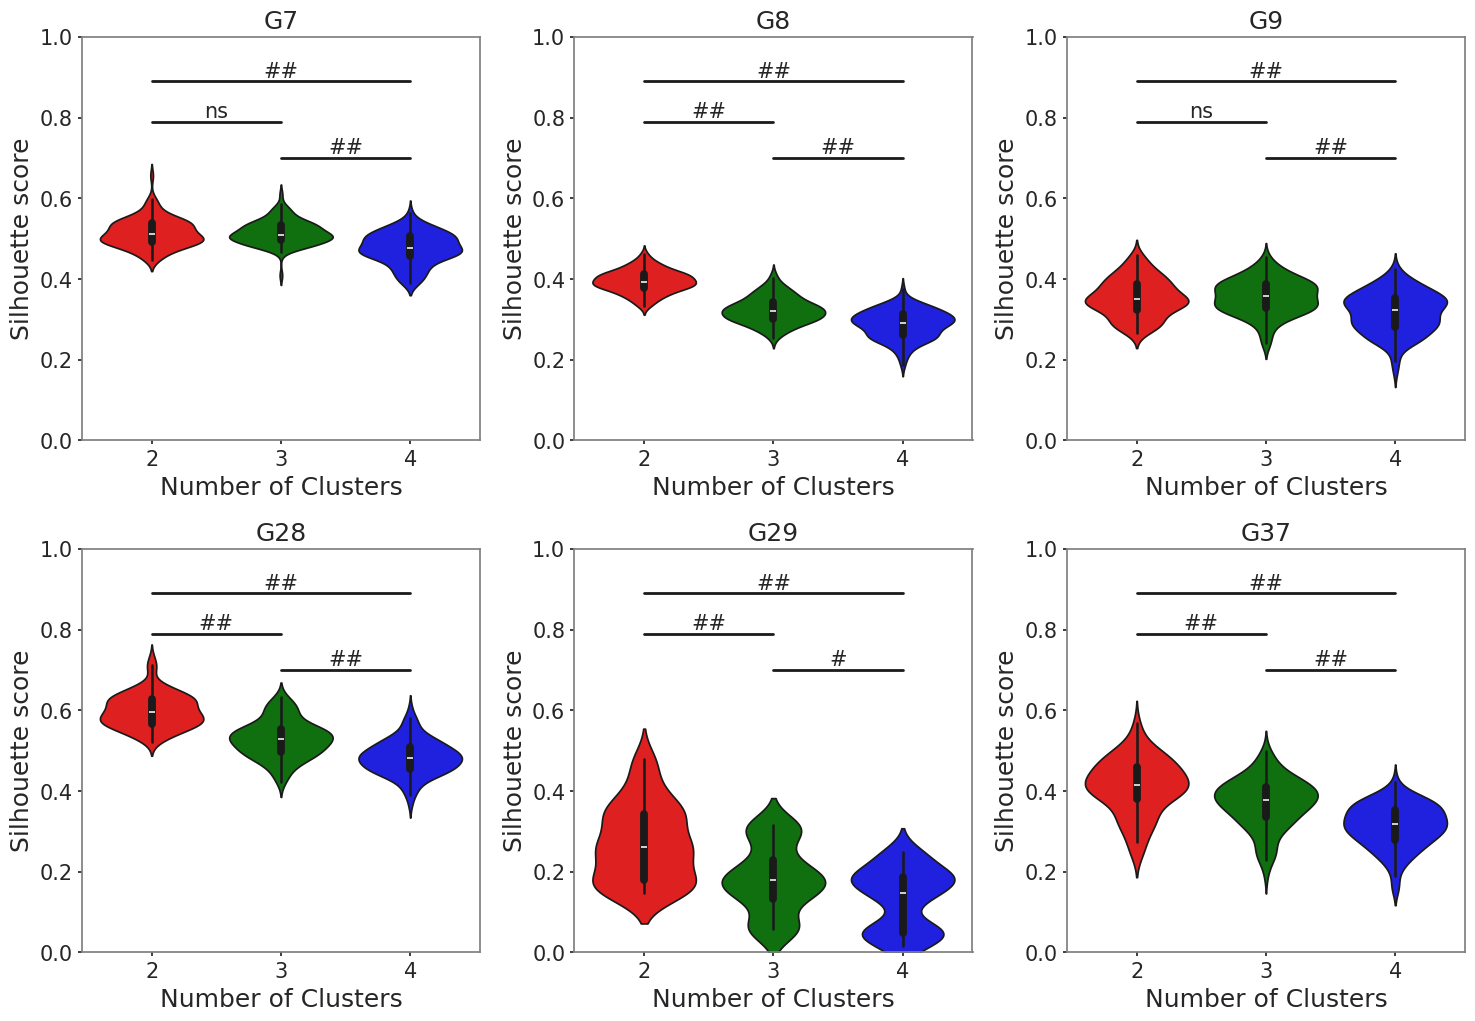

In [83]:
# Create a 3x3 grid layout for plotting silhouette score distributions
plt.figure(figsize=(15, 15))  # Set overall figure size

# Define subplot axes for each animal/group
ax1 = plt.subplot(3, 3, 1)
ax2 = plt.subplot(3, 3, 2)
ax3 = plt.subplot(3, 3, 3)
ax4 = plt.subplot(3, 3, 4)
ax5 = plt.subplot(3, 3, 5)
ax6 = plt.subplot(3, 3, 6)

# Iterate over bootstrapped stimulation datasets
for ind, stim_csv_fname in enumerate(boot_file_paths):
    # Load stimulation data and raw traces
    data_stim, cells_traces_tot_old = load_data(stim_csv_fname)

    # Filter for UCN3+ GABAergic neurons
    data_stim_tot, n_cells = process_data(data_stim, cells_traces_tot_old)

    # Normalise each trace to its own min/max (row-wise)
    normalised_data_stim_tot = minmax_scale(data_stim_tot, axis=1)

    # Slice stimulation period from normalised traces
    normalised_data_stim_2 = normalised_data_stim_tot[:, stim_onset:stim_offset]

    # Compute pairwise correlation-based distance matrix
    # Using 1 - Pearson correlation as a dissimilarity metric
    dist_cov_2 = pdist(scale(normalised_data_stim_2, axis=1),
                       lambda x, y: 1 - np.corrcoef(x, y)[0, 1])

    # Initialise array to store silhouette scores across bootstraps
    sil_score_2 = np.zeros((max_no_clusters - 1, n_resampling))

    # Loop over cluster numbers and bootstrap iterations
    for i, Ks_2 in enumerate(range(2, max_no_clusters + 1)):
        for j in range(n_resampling):
            # Resample 75% of cells for bootstrapping
            sampled_ids = np.random.choice(range(n_cells), int(0.75 * n_cells), replace=False)
            sampled_data = squareform(dist_cov_2)[sampled_ids, :][:, sampled_ids]

            # Apply hierarchical clustering with average linkage
            ac = AgglomerativeClustering(n_clusters=Ks_2, metric='precomputed',
                                         linkage='average', compute_distances=True).fit(sampled_data)

            # Compute silhouette score using precomputed distances
            sil_score_2[i, j] = silhouette_score(sampled_data, ac.labels_, metric='precomputed')

    # Select subplot axis based on file name prefix
    file_name = os.path.split(stim_csv_fname)[-1]
    ax = {
        'G7': ax1, 'G8': ax2, 'G9': ax3,
        'G28': ax4, 'G29': ax5, 'G37': ax6
    }.get(file_name.split(' ')[0], None)

    if ax:
        # Plot silhouette score distributions as violin plots
        for k, colour in enumerate(['red', 'green', 'blue']):  # Cluster sizes: 2, 3, 4
            df = pd.DataFrame({'x': np.repeat([k], len(sil_score_2[k, :])), 'y': sil_score_2[k, :]})
            sns.violinplot(x="x", y="y", data=df, color=colour, linecolor='k', ax=ax)

        # Perform Dunn's test for post-hoc comparisons
        p_vals = posthoc_dunn(sil_score_2, p_adjust='fdr_bh')

        # Annotate significance between cluster numbers
        ax.plot([0, 1], [0.79, 0.79], 'k-')  # 2 vs 3
        ax.plot([1, 2], [0.7, 0.7], 'k-')    # 3 vs 4
        ax.plot([0, 2], [0.89, 0.89], 'k-')  # 2 vs 4
        ax.annotate(pval_to_star(p_vals[1][2]), (0.5, 0.8), ha='center')
        ax.annotate(pval_to_star(p_vals[2][3]), (1.5, 0.71), ha='center')
        ax.annotate(pval_to_star(p_vals[1][3]), (1, 0.9), ha='center')

# Configure subplot titles and axis labels
for idx, title in enumerate(['G7', 'G8', 'G9', 'G28', 'G29', 'G37'], start=1):
    ax = plt.subplot(3, 3, idx)
    ax.set_title(title)  # Animal/group ID
    ax.set_ylim(0, 1)  # Score range
    ax.set_ylabel('Silhouette score')
    ax.set_xlabel('Number of Clusters')
    ax.set_xticklabels([2, 3, 4, '', 2, 3, 4])  # Cluster labels

# Final layout and export
plt.tight_layout()  # Optimise spacing
# plt.savefig('./gdrive/My Drive/FigS3_corr_revised.svg', dpi=300)  # Save figure
plt.show()  # Display plot

# 🖼️ Figure S4 (SLxCorr)

/tmp/ipykernel_332565/4008998835.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([2, 3, 4, '', 2, 3, 4])  # Cluster labels
/tmp/ipykernel_332565/4008998835.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([2, 3, 4, '', 2, 3, 4])  # Cluster labels
/tmp/ipykernel_332565/4008998835.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([2, 3, 4, '', 2, 3, 4])  # Cluster labels
/tmp/ipykernel_332565/4008998835.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([2, 3, 4, '', 2, 3, 4])  # Cluster labels
/tmp/ipykernel_332565/4008998835.py:78: UserWarning: set_ticklabels() should

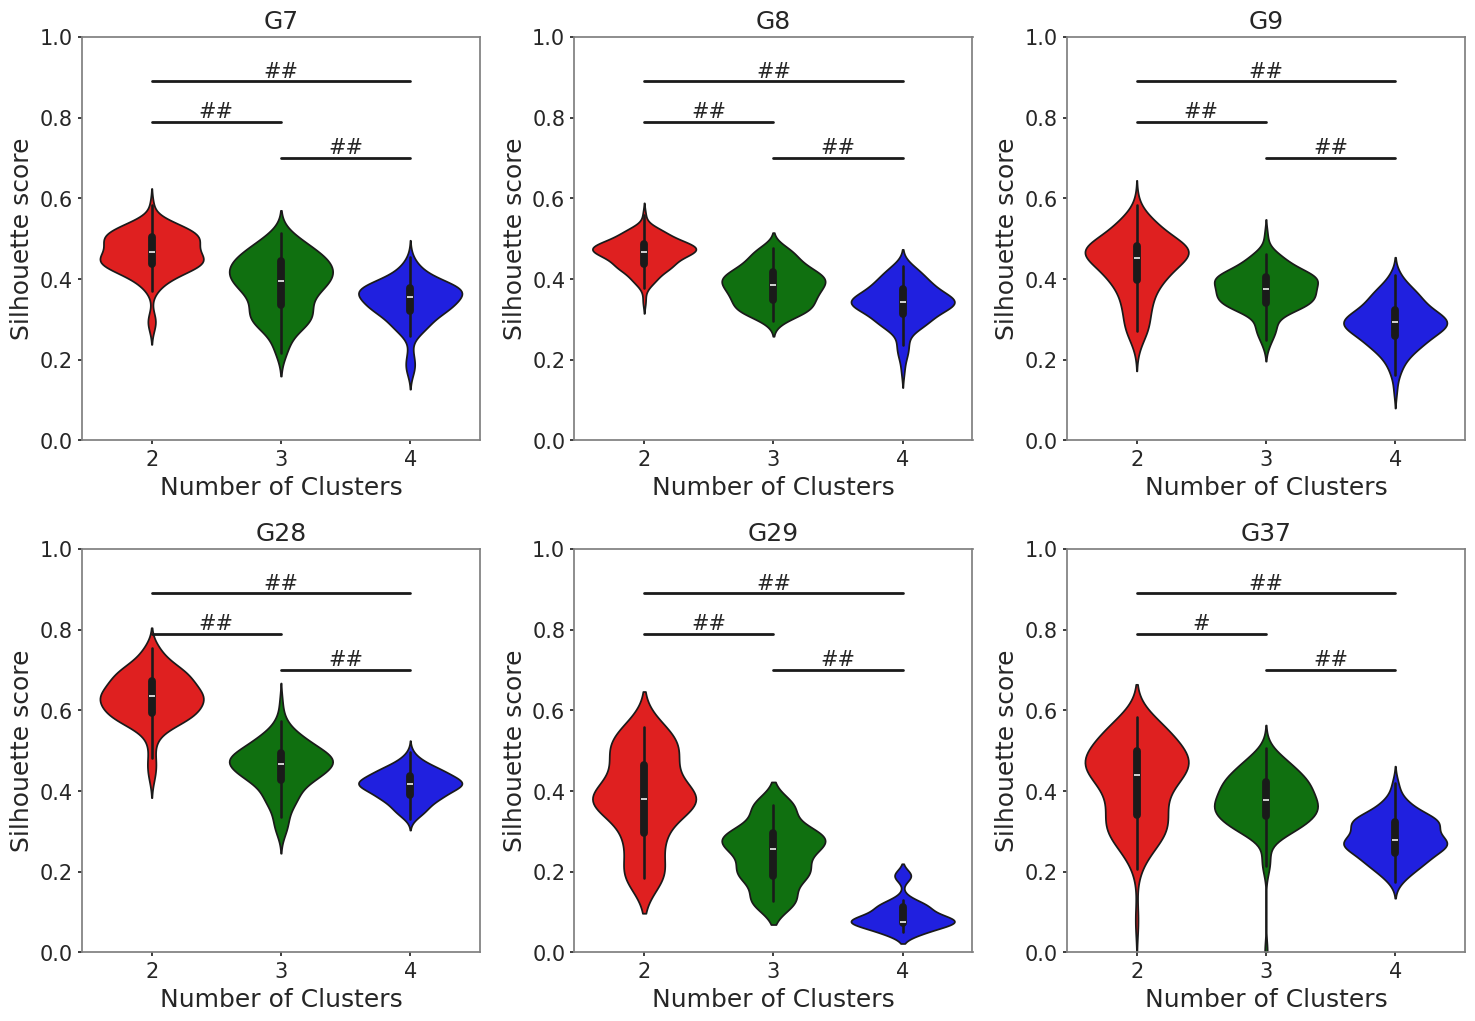

In [84]:
# Create a 3x3 grid layout for plotting silhouette score distributions
plt.figure(figsize=(15, 15))  # Set overall figure size

# Define subplot axes for each animal/group
ax1 = plt.subplot(3, 3, 1)
ax2 = plt.subplot(3, 3, 2)
ax3 = plt.subplot(3, 3, 3)
ax4 = plt.subplot(3, 3, 4)
ax5 = plt.subplot(3, 3, 5)
ax6 = plt.subplot(3, 3, 6)

# Iterate over bootstrapped stimulation datasets
for ind, stim_csv_fname in enumerate(boot_file_paths):
    # Load stimulation data and raw traces
    data_stim, cells_traces_tot_old = load_data(stim_csv_fname)

    # Filter for UCN3+ GABAergic neurons
    data_stim_tot, n_cells = process_data(data_stim, cells_traces_tot_old)

    # Normalise each trace to its own min/max (row-wise)
    normalised_data_stim_tot = minmax_scale(data_stim_tot, axis=1)

    # Slice stimulation period from normalised traces
    normalised_data_stim_2 = normalised_data_stim_tot[:, stim_onset:stim_offset]

    # Compute pairwise signed lagged correlation distance matrix
    dist_corr_2 = pdist(scale(normalised_data_stim_2, axis=1),
                        lambda x, y: 1 - signed_lagged_corr(x, y)[0])

    # Initialise array to store silhouette scores across bootstraps
    sil_score_2 = np.zeros((max_no_clusters - 1, n_resampling))

    # Loop over cluster numbers and bootstrap iterations
    for i, Ks_2 in enumerate(range(2, max_no_clusters + 1)):
        for j in range(n_resampling):
            # Resample 75% of cells for bootstrapping
            sampled_ids = np.random.choice(range(n_cells), int(0.75 * n_cells), replace=False)
            sampled_data = squareform(dist_corr_2)[sampled_ids, :][:, sampled_ids]

            # Apply hierarchical clustering with average linkage
            ac = AgglomerativeClustering(n_clusters=Ks_2, metric='precomputed',
                                         linkage='average', compute_distances=True).fit(sampled_data)

            # Compute silhouette score using precomputed distances
            sil_score_2[i, j] = silhouette_score(sampled_data, ac.labels_, metric='precomputed')

    # Select subplot axis based on file name prefix
    file_name = os.path.split(stim_csv_fname)[-1]
    ax = {
        'G7': ax1, 'G8': ax2, 'G9': ax3,
        'G28': ax4, 'G29': ax5, 'G37': ax6
    }.get(file_name.split(' ')[0], None)

    if ax:
        # Plot silhouette score distributions as violin plots
        for k, colour in enumerate(['red', 'green', 'blue']):  # Cluster sizes: 2, 3, 4
            df = pd.DataFrame({'x': np.repeat([k], len(sil_score_2[k, :])), 'y': sil_score_2[k, :]})
            sns.violinplot(x="x", y="y", data=df, color=colour, linecolor='k', ax=ax)

        # Perform Dunn's test for post-hoc comparisons
        p_vals = posthoc_dunn(sil_score_2, p_adjust='fdr_bh')

        # Annotate significance between cluster numbers
        ax.plot([0, 1], [0.79, 0.79], 'k-')  # 2 vs 3
        ax.plot([1, 2], [0.7, 0.7], 'k-')    # 3 vs 4
        ax.plot([0, 2], [0.89, 0.89], 'k-')  # 2 vs 4
        ax.annotate(pval_to_star(p_vals[1][2]), (0.5, 0.8), ha='center')
        ax.annotate(pval_to_star(p_vals[2][3]), (1.5, 0.71), ha='center')
        ax.annotate(pval_to_star(p_vals[1][3]), (1, 0.9), ha='center')

# Configure subplot titles and axis labels
for idx, title in enumerate(['G7', 'G8', 'G9', 'G28', 'G29', 'G37'], start=1):
    ax = plt.subplot(3, 3, idx)
    ax.set_title(title)  # Animal/group ID
    ax.set_ylim(0, 1)  # Score range
    ax.set_ylabel('Silhouette score')
    ax.set_xlabel('Number of Clusters')
    ax.set_xticklabels([2, 3, 4, '', 2, 3, 4])  # Cluster labels

# Final layout and export
plt.tight_layout()  # Optimise spacing
plt.show()  # Display plot

# 🖼️ Figure S5 (kmeans)

/tmp/ipykernel_332565/1144629990.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([2, 3, 4, '', 2, 3, 4])  # Cluster labels
/tmp/ipykernel_332565/1144629990.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([2, 3, 4, '', 2, 3, 4])  # Cluster labels
/tmp/ipykernel_332565/1144629990.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([2, 3, 4, '', 2, 3, 4])  # Cluster labels
/tmp/ipykernel_332565/1144629990.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([2, 3, 4, '', 2, 3, 4])  # Cluster labels
/tmp/ipykernel_332565/1144629990.py:77: UserWarning: set_ticklabels() should

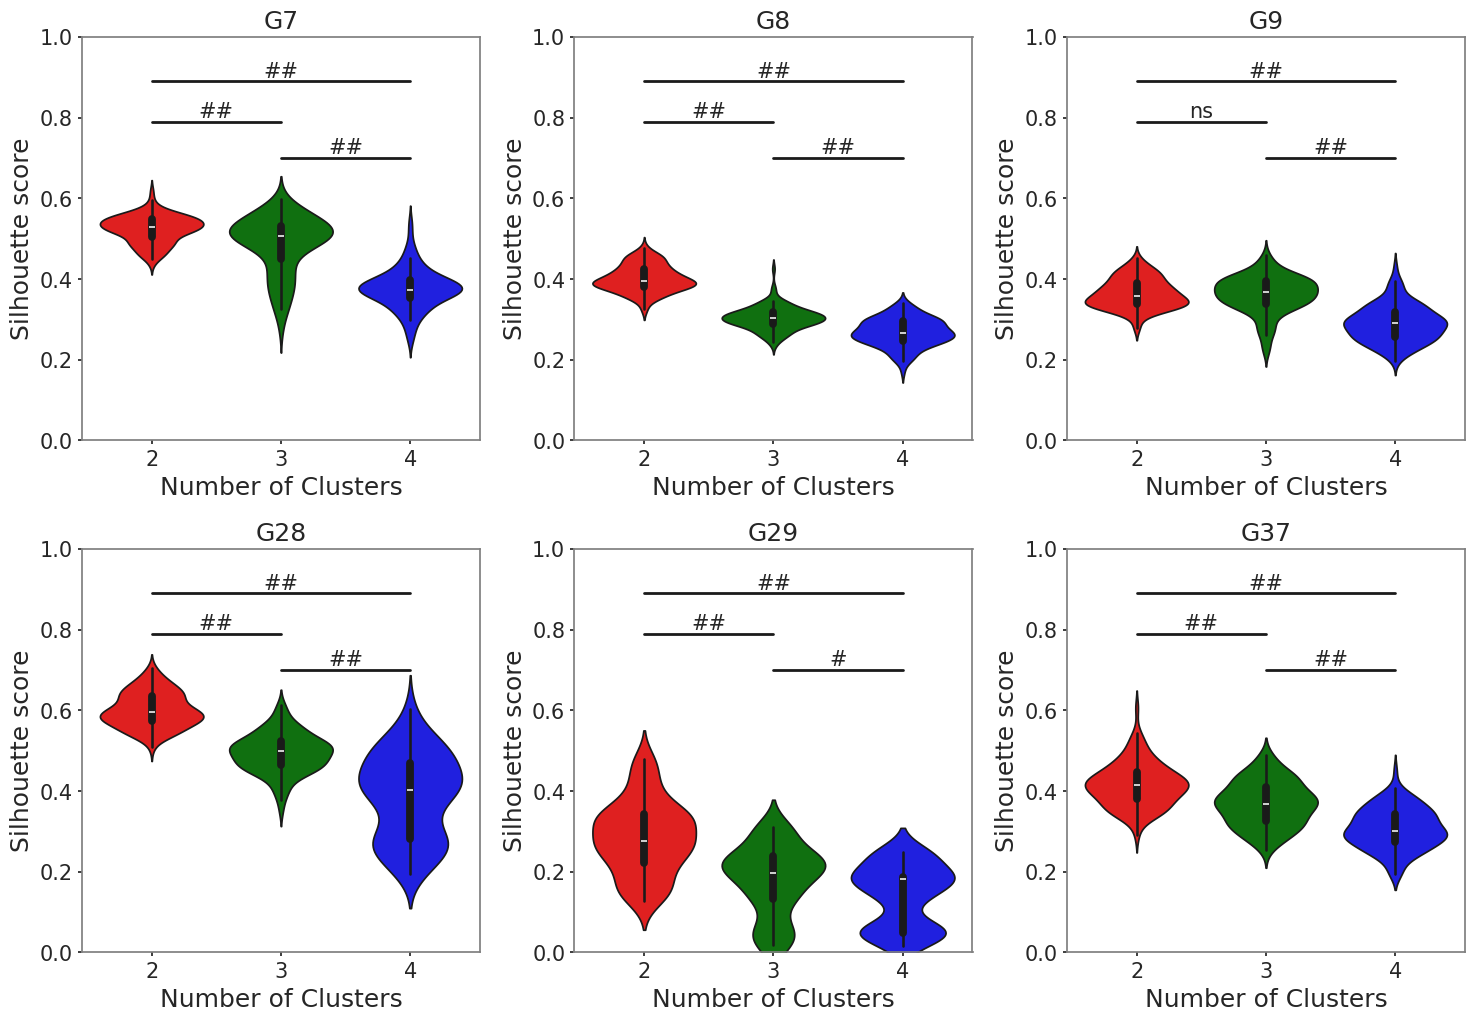

In [85]:
# Create a 3x3 grid for plotting silhouette score distributions
plt.figure(figsize=(15, 15))  # Set overall figure size

# Define subplot axes for each animal/group
ax1 = plt.subplot(3, 3, 1)
ax2 = plt.subplot(3, 3, 2)
ax3 = plt.subplot(3, 3, 3)
ax4 = plt.subplot(3, 3, 4)
ax5 = plt.subplot(3, 3, 5)
ax6 = plt.subplot(3, 3, 6)

# Iterate over bootstrapped stimulation datasets
for ind, stim_csv_fname in enumerate(boot_file_paths):
    # Load stimulation data and raw traces
    data_stim, cells_traces_tot_old = load_data(stim_csv_fname)

    # Filter for UCN3+ GABAergic neurons
    data_stim_tot, n_cells = process_data(data_stim, cells_traces_tot_old)

    # Normalise each trace to its own min/max (row-wise)
    normalised_data_stim_tot = minmax_scale(data_stim_tot, axis=1)

    # Slice stimulation period from normalised traces
    normalised_data_stim_2 = normalised_data_stim_tot[:, stim_onset:stim_offset]

    # Compute pairwise correlation-based distance matrix
    dist_corr_2 = pdist(scale(normalised_data_stim_2, axis=1),
                        lambda x, y: 1 - np.corrcoef(x, y)[0, 1])

    # Initialise array to store silhouette scores across bootstraps
    sil_score_2 = np.zeros((max_no_clusters - 1, n_resampling))

    # Loop over cluster numbers and bootstrap iterations
    for i, Ks_2 in enumerate(range(2, max_no_clusters + 1)):
        for j in range(n_resampling):
            # Resample 75% of cells for bootstrapping
            sampled_ids = np.random.choice(range(n_cells), int(0.75 * n_cells), replace=False)
            sampled_data = squareform(dist_corr_2)[sampled_ids, :][:, sampled_ids]

            # Apply K-means clustering to resampled data
            km = KMeans(n_clusters=Ks_2, n_init=10, max_iter=100).fit(sampled_data)

            # Compute silhouette score using precomputed distances
            sil_score_2[i, j] = silhouette_score(sampled_data, km.labels_, metric='precomputed')

    # Select subplot axis based on file name prefix
    file_name = os.path.split(stim_csv_fname)[-1]
    ax = {
        'G7': ax1, 'G8': ax2, 'G9': ax3,
        'G28': ax4, 'G29': ax5, 'G37': ax6
    }.get(file_name.split(' ')[0], None)

    if ax:
        # Plot silhouette score distributions as violin plots
        for k, colour in enumerate(['red', 'green', 'blue']):
            df = pd.DataFrame({'x': np.repeat([k], len(sil_score_2[k, :])), 'y': sil_score_2[k, :]})
            sns.violinplot(x="x", y="y", data=df, color=colour, linecolor='k', ax=ax)

        # Perform Dunn's test for post-hoc comparisons
        p_vals = posthoc_dunn(sil_score_2, p_adjust='fdr_bh')

        # Annotate significance between cluster numbers
        ax.plot([0, 1], [0.79, 0.79], 'k-')  # 2 vs 3
        ax.plot([1, 2], [0.7, 0.7], 'k-')    # 3 vs 4
        ax.plot([0, 2], [0.89, 0.89], 'k-')  # 2 vs 4
        ax.annotate(pval_to_star(p_vals[1][2]), (0.5, 0.8), ha='center')
        ax.annotate(pval_to_star(p_vals[2][3]), (1.5, 0.71), ha='center')
        ax.annotate(pval_to_star(p_vals[1][3]), (1, 0.9), ha='center')

# Configure subplot titles and axis labels
for idx, title in enumerate(['G7', 'G8', 'G9', 'G28', 'G29', 'G37'], start=1):
    ax = plt.subplot(3, 3, idx)
    ax.set_title(title)  # Animal/group ID
    ax.set_ylim(0, 1)  # Score range
    ax.set_ylabel('Silhouette score')
    ax.set_xlabel('Number of Clusters')
    ax.set_xticklabels([2, 3, 4, '', 2, 3, 4])  # Cluster labels

# Final layout and export
plt.tight_layout()
# plt.savefig('./gdrive/My Drive/FigS5_kmeans_revised.svg', dpi=300)
plt.show()

# 🖼️ Figure S6 (stim. frequency)

In [86]:
# Distance metrics for control condition at 5 Hz stimulation
# Each value likely represents a summary statistic (e.g., mean trace distance) per cell or ROI
control_dist_5Hz = [0.3880, 0.5961, 0.6274, 0.2502, 0.3371, 0.3458, 0.3078, 0.4944, 0.3302, 0.3775, 0.5336, 0.4705]

# Distance metrics for stimulated condition at 5 Hz
# Larger sample size suggests more cells or trials were analyzed under stimulation
stim_dist_5Hz = [0.3697, 0.3987, 0.3547, 0.4152, 0.3759, 0.3717, 0.3927, 0.4157, 0.3807, 0.3770,
                 0.3625, 0.2734, 0.3256, 0.4289, 0.3702, 0.3674, 0.4469, 0.4589, 0.4747, 0.3439]

# Distance metrics for control condition at 20 Hz stimulation
# Values may reflect baseline or spontaneous activity patterns at higher frequency context
control_dist_20Hz = [0.6933, 0.5293, 0.5910, 0.4005, 0.3390, 0.4714, 0.5060, 0.4065, 0.4393, 0.5510, 0.4441, 0.4634]

# Distance metrics for stimulated condition at 20 Hz
# Used to assess how stimulation alters trace similarity or variability at higher frequency
stim_dist_20Hz = [0.3857, 0.4040, 0.3860, 0.3939, 0.4034, 0.3658, 0.4081, 0.4177, 0.4064, 0.3816,
                  0.2990, 0.4429, 0.3006, 0.4532, 0.3107, 0.4206, 0.4544, 0.4467, 0.4376, 0.4959]

/tmp/ipykernel_332565/2756402767.py:5: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  uniq = pd.unique(animals)
/home/kn356/miniconda_env/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/kn356/miniconda_env/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/kn356/miniconda_env/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


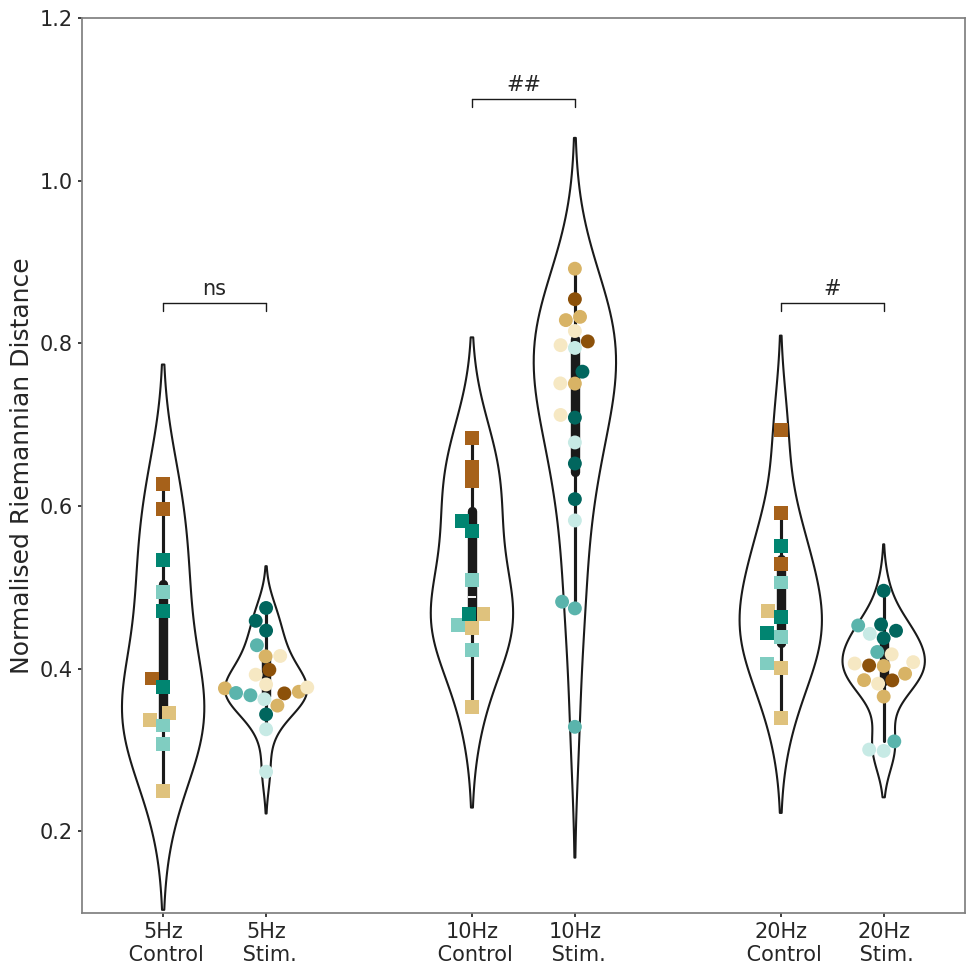

In [87]:
# =========================
# Helpers
# =========================
def make_palette(animals, colors):
    uniq = pd.unique(animals)
    if len(uniq) != len(colors):
        raise ValueError("Number of animals and colors must match")
    return dict(zip(uniq, colors))

palette_ctrl = make_palette(control_animal, colors_ctrl)
palette_stim = make_palette(stim_animal, mycolors)

x_order = [0, 1, 3, 4, 6, 7, 8, 9 ]

def violin_swarm(xpos, values, animals, palette, marker):
    df = pd.DataFrame({
        "x": np.repeat(xpos, len(values)),
        "y": values,
        "c": animals
    })

    sns.violinplot(
        x="x", y="y", data=df,
        order=x_order,
        fill=False, color="k",
        linewidth=1.5,
        ax=ax
    )

    sns.swarmplot(
        x="x", y="y", hue="c", data=df,
        order=x_order,
        palette=palette,
        size=10,
        marker=marker,
        legend=False,
        ax=ax
    )

# =========================
# Figure
# =========================
fig = plt.figure(figsize=(10, 10))
ax = plt.subplot(1, 1, 1)

# --- 5 Hz ---
violin_swarm(0, control_dist_5Hz, control_animal, palette_ctrl, "s")
violin_swarm(1, stim_dist_5Hz,    stim_animal,    palette_stim, "o")

# --- 10 Hz ---
violin_swarm(4, control_dist, control_animal, palette_ctrl, "s")
violin_swarm(6, stim_dist,    stim_animal,    palette_stim, "o")

# --- 20 Hz ---
violin_swarm(8, control_dist_20Hz, control_animal, palette_ctrl, "s")
violin_swarm(9, stim_dist_20Hz,    stim_animal,    palette_stim, "o")

# =========================
# Axes
# =========================
ax.set_ylim(0.1, 1.2)
ax.set_ylabel("Normalised Riemannian Distance")
ax.set_xlabel("")
ax.set_xticks(
    [0, 1, 3, 4, 6, 7],
    labels=[
        "5Hz\n Control", "5Hz\n Stim.",
        "10Hz\n Control", "10Hz\n Stim.",
        "20Hz\n Control", "20Hz\n Stim."
    ]
)

# =========================
# Statistics
# =========================
# 5 Hz
ax.plot([0, 1], [0.85, 0.85], "k-", lw=1)
ax.plot([0, 0], [0.85, 0.84], "k-", lw=1)
ax.plot([1, 1], [0.85, 0.84], "k-", lw=1)
_, p = kruskal(control_dist_5Hz, stim_dist_5Hz)
ax.annotate(pval_to_star(p), (0.5, 0.86), ha="center")

# 10 Hz
ax.plot([3, 4], [1.1, 1.1], "k-", lw=1)
ax.plot([3, 3], [1.1, 1.09], "k-", lw=1)
ax.plot([4, 4], [1.1, 1.09], "k-", lw=1)
_, p = kruskal(control_dist, stim_dist)
ax.annotate(pval_to_star(p), (3.5, 1.11), ha="center")

# 20 Hz
ax.plot([6, 7], [0.85, 0.85], "k-", lw=1)
ax.plot([6, 6], [0.85, 0.84], "k-", lw=1)
ax.plot([7, 7], [0.85, 0.84], "k-", lw=1)
_, p = kruskal(control_dist_20Hz, stim_dist_20Hz)
ax.annotate(pval_to_star(p), (6.5, 0.86), ha="center")

plt.tight_layout()
plt.savefig("Fig_dist_violin_swarm.svg", dpi=600, bbox_inches="tight")
plt.show()

# 📚 Used Libraries

In [88]:
# List all currently imported libraries in the global namespace
import types

def list_imported_modules():
    return sorted(
        val.__name__ for name, val in globals().items()
        if isinstance(val, types.ModuleType)
    )

# Display the list
set(list_imported_modules())

{'builtins',
 'colorcet',
 'matplotlib.gridspec',
 'matplotlib.pyplot',
 'numpy',
 'os',
 'pandas',
 'seaborn',
 'statsmodels.formula.api',
 'types',
 'warnings'}